In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Extract Dataset from API

In [24]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 14.5995,
	"longitude": 120.9842,
	"start_date": "2023-01-01",
	"end_date": "2026-03-15",
	"daily": ["temperature_2m_mean", "relative_humidity_2m_mean", "wind_speed_10m_mean", "apparent_temperature_mean", "dew_point_2m_mean", "surface_pressure_mean", "pressure_msl_mean", "precipitation_sum", "winddirection_10m_dominant", "wind_gusts_10m_mean", "et0_fao_evapotranspiration", "rain_sum", "cloud_cover_mean", "soil_moisture_0_to_100cm_mean", "soil_temperature_0_to_100cm_mean"],
	"timezone": "Asia/Bangkok",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(1).ValuesAsNumpy()
daily_wind_speed_10m_mean = daily.Variables(2).ValuesAsNumpy()
daily_apparent_temperature_mean = daily.Variables(3).ValuesAsNumpy()
daily_dew_point_2m_mean = daily.Variables(4).ValuesAsNumpy()
daily_surface_pressure_mean = daily.Variables(5).ValuesAsNumpy()
daily_pressure_msl_mean = daily.Variables(6).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(7).ValuesAsNumpy()
daily_winddirection_10m_dominant = daily.Variables(8).ValuesAsNumpy()
daily_wind_gusts_10m_mean = daily.Variables(9).ValuesAsNumpy()
daily_et0_fao_evapotranspiration = daily.Variables(10).ValuesAsNumpy()
daily_rain_sum = daily.Variables(11).ValuesAsNumpy()
daily_cloud_cover_mean = daily.Variables(12).ValuesAsNumpy()
daily_soil_moisture_0_to_100cm_mean = daily.Variables(13).ValuesAsNumpy()
daily_soil_temperature_0_to_100cm_mean = daily.Variables(14).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["wind_speed_10m_mean"] = daily_wind_speed_10m_mean
daily_data["apparent_temperature_mean"] = daily_apparent_temperature_mean
daily_data["dew_point_2m_mean"] = daily_dew_point_2m_mean
daily_data["surface_pressure_mean"] = daily_surface_pressure_mean
daily_data["pressure_msl_mean"] = daily_pressure_msl_mean
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["winddirection_10m_dominant"] = daily_winddirection_10m_dominant
daily_data["wind_gusts_10m_mean"] = daily_wind_gusts_10m_mean
daily_data["et0_fao_evapotranspiration"] = daily_et0_fao_evapotranspiration
daily_data["rain_sum"] = daily_rain_sum
daily_data["cloud_cover_mean"] = daily_cloud_cover_mean
daily_data["soil_moisture_0_to_100cm_mean"] = daily_soil_moisture_0_to_100cm_mean
daily_data["soil_temperature_0_to_100cm_mean"] = daily_soil_temperature_0_to_100cm_mean

daily_dataframe = pd.DataFrame(data = daily_data)


Coordinates: 14.586995124816895°N 121.0027847290039°E
Elevation: 9.0 m asl
Timezone: b'Asia/Bangkok'b'GMT+7'
Timezone difference to GMT+0: 25200s


In [25]:
display(daily_dataframe.head(10))
print(f'Dataframe Shape: {daily_dataframe.shape}')

,date,temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_mean,apparent_temperature_mean,dew_point_2m_mean,surface_pressure_mean,pressure_msl_mean,precipitation_sum,winddirection_10m_dominant,wind_gusts_10m_mean,et0_fao_evapotranspiration,rain_sum,cloud_cover_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean
0,2023-01-01 00:00:00+00:00,26.127083,86.250916,4.115713,31.407234,23.575005,1012.351074,1013.391663,11.3,126.764511,13.110000,2.977766,11.3,83.000000,0.338259,27.187998
1,2023-01-02 00:00:00+00:00,26.804167,80.771400,6.351832,31.505302,22.968750,1011.758301,1012.795837,1.3,56.159882,14.340000,3.787254,1.3,56.333332,0.338307,27.274981
2,2023-01-03 00:00:00+00:00,25.902084,84.100639,5.997589,30.590929,22.937500,1011.160095,1012.199890,6.8,39.880577,19.455000,3.177299,6.8,94.750000,0.340017,27.305687
3,2023-01-04 00:00:00+00:00,25.895836,80.230721,8.538137,29.651525,22.118750,1010.947693,1011.987610,5.3,21.336927,22.095001,2.873123,5.3,97.458336,0.338750,27.193230
4,2023-01-05 00:00:00+00:00,24.845833,92.607216,4.810213,29.968925,23.541664,1011.555908,1012.600037,6.6,356.877899,14.984998,2.182856,6.6,92.708336,0.348970,27.017502
5,2023-01-06 00:00:00+00:00,24.979170,91.180092,5.839230,29.882288,23.408331,1012.367981,1013.412537,17.6,83.940025,16.574999,2.180280,17.6,92.208336,0.359660,26.901915
6,2023-01-07 00:00:00+00:00,25.475000,80.614845,9.053674,29.017904,21.589582,1012.132324,1013.175049,0.2,81.424042,19.275000,3.872749,0.2,43.541668,0.355975,26.984629
7,2023-01-08 00:00:00+00:00,24.620834,79.579018,8.850080,27.598701,20.612499,1013.569519,1014.616699,1.0,83.865181,18.615000,3.542947,1.0,48.916668,0.353894,26.925356
8,2023-01-09 00:00:00+00:00,25.116667,78.293564,6.398859,28.625834,20.837502,1013.217468,1014.262451,0.0,50.964481,14.655001,3.446327,0.0,64.041664,0.351352,26.906775
9,2023-01-10 00:00:00+00:00,25.129168,80.516777,5.752269,29.039606,21.414583,1011.419373,1012.462463,0.1,182.121063,13.589999,3.357203,0.1,99.666664,0.348828,26.969812


Dataframe Shape: (1170, 16)


In [26]:
daily_dataframe.columns.to_list()

['date',
 'temperature_2m_mean',
 'relative_humidity_2m_mean',
 'wind_speed_10m_mean',
 'apparent_temperature_mean',
 'dew_point_2m_mean',
 'surface_pressure_mean',
 'pressure_msl_mean',
 'precipitation_sum',
 'winddirection_10m_dominant',
 'wind_gusts_10m_mean',
 'et0_fao_evapotranspiration',
 'rain_sum',
 'cloud_cover_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean']

In [38]:
daily_dataframe.dtypes

date                                datetime64[s, UTC]
temperature_2m_mean                            float32
relative_humidity_2m_mean                      float32
wind_speed_10m_mean                            float32
apparent_temperature_mean                      float32
dew_point_2m_mean                              float32
surface_pressure_mean                          float32
pressure_msl_mean                              float32
precipitation_sum                              float32
winddirection_10m_dominant                     float32
wind_gusts_10m_mean                            float32
et0_fao_evapotranspiration                     float32
rain_sum                                       float32
cloud_cover_mean                               float32
soil_moisture_0_to_100cm_mean                  float32
soil_temperature_0_to_100cm_mean               float32
dtype: object

### Augmented Dickey-Fuller Test

In [34]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
features = [column for column in daily_dataframe.columns if column != 'date']

results = []

for column in features:
    result = adfuller(daily_dataframe[column])
    results.append({
        'Feature': column,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationarity': 'Yes' if result[1] <= 0.05 else 'No'
    })

adf_table = pd.DataFrame(results)
display(adf_table)

,Feature,ADF Statistic,p-value,Stationarity
0,temperature_2m_mean,-3.942371,1.744231e-03,Yes
1,relative_humidity_2m_mean,-4.760941,6.455733e-05,Yes
2,wind_speed_10m_mean,-10.247778,4.569402e-18,Yes
3,apparent_temperature_mean,-4.176621,7.215831e-04,Yes
4,dew_point_2m_mean,-1.290086,6.336957e-01,No
5,surface_pressure_mean,-3.777701,3.143882e-03,Yes
6,pressure_msl_mean,-3.775816,3.164674e-03,Yes
7,precipitation_sum,-7.651399,1.785340e-11,Yes
8,winddirection_10m_dominant,-3.650910,4.859092e-03,Yes
9,wind_gusts_10m_mean,-10.031173,1.583566e-17,Yes


In [28]:
daily_dataframe['dew_point_2m_mean'] = daily_dataframe['dew_point_2m_mean'].diff()
dew_point_adf = adfuller(daily_dataframe['dew_point_2m_mean'].dropna())
print(f'dew_point_2m_mean First Difference: {'Stationary' if dew_point_adf[1] <= 0.05 else 'Not Stationary'}')

dew_point_2m_mean First Difference: Stationary


In [ ]:
# Drop all rows with NaN
daily_dataframe.dropna(inplace = True)

### Cut the Data into Folds

In [39]:
# Define the exact boundaries from your table
folds_configuration = [
    {
        'fold_id': 1,
        'season': 'Habagat (SW Monsoon)',
        'train_start': '2023-01-01',
        'train_end': '2025-08-31',
        'test_start': '2025-09-01',
        'test_end': '2025-09-14'
    },
    {
        'fold_id': 2,
        'season': 'Transition (Post-Habagat)',
        'train_start': '2023-01-01',
        'train_end': '2025-10-31',
        'test_start': '2025-11-01',
        'test_end': '2025-11-14'
    },
    {
        'fold_id': 3,
        'season': 'Amihan (NE Monsoon)',
        'train_start': '2023-01-01',
        'train_end': '2026-01-31',
        'test_start': '2026-02-01',
        'test_end': '2026-02-14'
    },
    {
        'fold_id': 4,
        'season': 'Dry Season (Hot/Dry)',
        'train_start': '2023-01-01',
        'train_end': '2026-02-28',
        'test_start': '2026-03-01',
        'test_end': '2026-03-14'
    }
]

# Slice the data into a dictionary
seasonal_folds = {}

for configuration in folds_configuration:
    name = configuration['season']
    
    train_slice = daily_dataframe[(daily_dataframe['date'] >= configuration['train_start']) & 
                                  (daily_dataframe['date'] <= configuration['train_end'])].copy()
    
    test_slice = daily_dataframe[(daily_dataframe['date'] >= configuration['test_start']) & 
                                 (daily_dataframe['date'] <= configuration['test_end'])].copy()
    
    seasonal_folds[name] = {
        'train': train_slice,
        'test': test_slice
    }
    
    print(f"Slicing Complete for {name}:")
    print(f"   - Training Rows: {len(train_slice)}")
    print(f"   - Testing Rows:  {len(test_slice)}\n")

Slicing Complete for Habagat (SW Monsoon):
   - Training Rows: 973
   - Testing Rows:  14

Slicing Complete for Transition (Post-Habagat):
   - Training Rows: 1034
   - Testing Rows:  14

Slicing Complete for Amihan (NE Monsoon):
   - Training Rows: 1126
   - Testing Rows:  14

Slicing Complete for Dry Season (Hot/Dry):
   - Training Rows: 1154
   - Testing Rows:  14



### Principal Component Analysis

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [43]:
# Separate predictors and labels
predictor_columns = [column for column in daily_dataframe.columns if column not in ['date','temperature_2m_mean','relative_humidity_2m_mean','wind_speed_10m_mean']]
label_columns = ['temperature_2m_mean','relative_humidity_2m_mean','wind_speed_10m_mean']

In [47]:
processed_folds = {}

for season_name, data in seasonal_folds.items():
    print(f"--- Processing Fold: {season_name} ---")
    
    # Separate Predictors and Labels for Train and Test
    X_train_raw = data['train'][predictor_columns]
    y_train = data['train'][label_columns]
    
    X_test_raw = data['test'][predictor_columns]
    y_test = data['test'][label_columns]
    
    # Standardize within the Fold (Fit on Train, Transform Both)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    # PCA: Fit on Training set
    # Set n_components=0.90 to keep 90% of variance, which may vary by season
    pca = PCA(n_components=0.90)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Extract Loadings
    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
        index=predictor_columns
    )
    
    # Store everything back for the ARIMAX step
    processed_folds[season_name] = {
        'X_train_pca': X_train_pca,
        'X_test_pca': X_test_pca,
        'y_train': y_train,
        'y_test': y_test,
        'pca_model': pca,
        'loadings': loadings,
        'n_components': pca.n_components_
    }
    
    print(f"      Success: Reduced 12 features to {pca.n_components_} components.")
    print(f"      Variance Explained: {pca.explained_variance_ratio_.sum():.2%}\n")

--- Processing Fold: Habagat (SW Monsoon) ---
      Success: Reduced 12 features to 7 components.
      Variance Explained: 93.85%

--- Processing Fold: Transition (Post-Habagat) ---
      Success: Reduced 12 features to 7 components.
      Variance Explained: 93.67%

--- Processing Fold: Amihan (NE Monsoon) ---
      Success: Reduced 12 features to 7 components.
      Variance Explained: 93.43%

--- Processing Fold: Dry Season (Hot/Dry) ---
      Success: Reduced 12 features to 7 components.
      Variance Explained: 93.39%



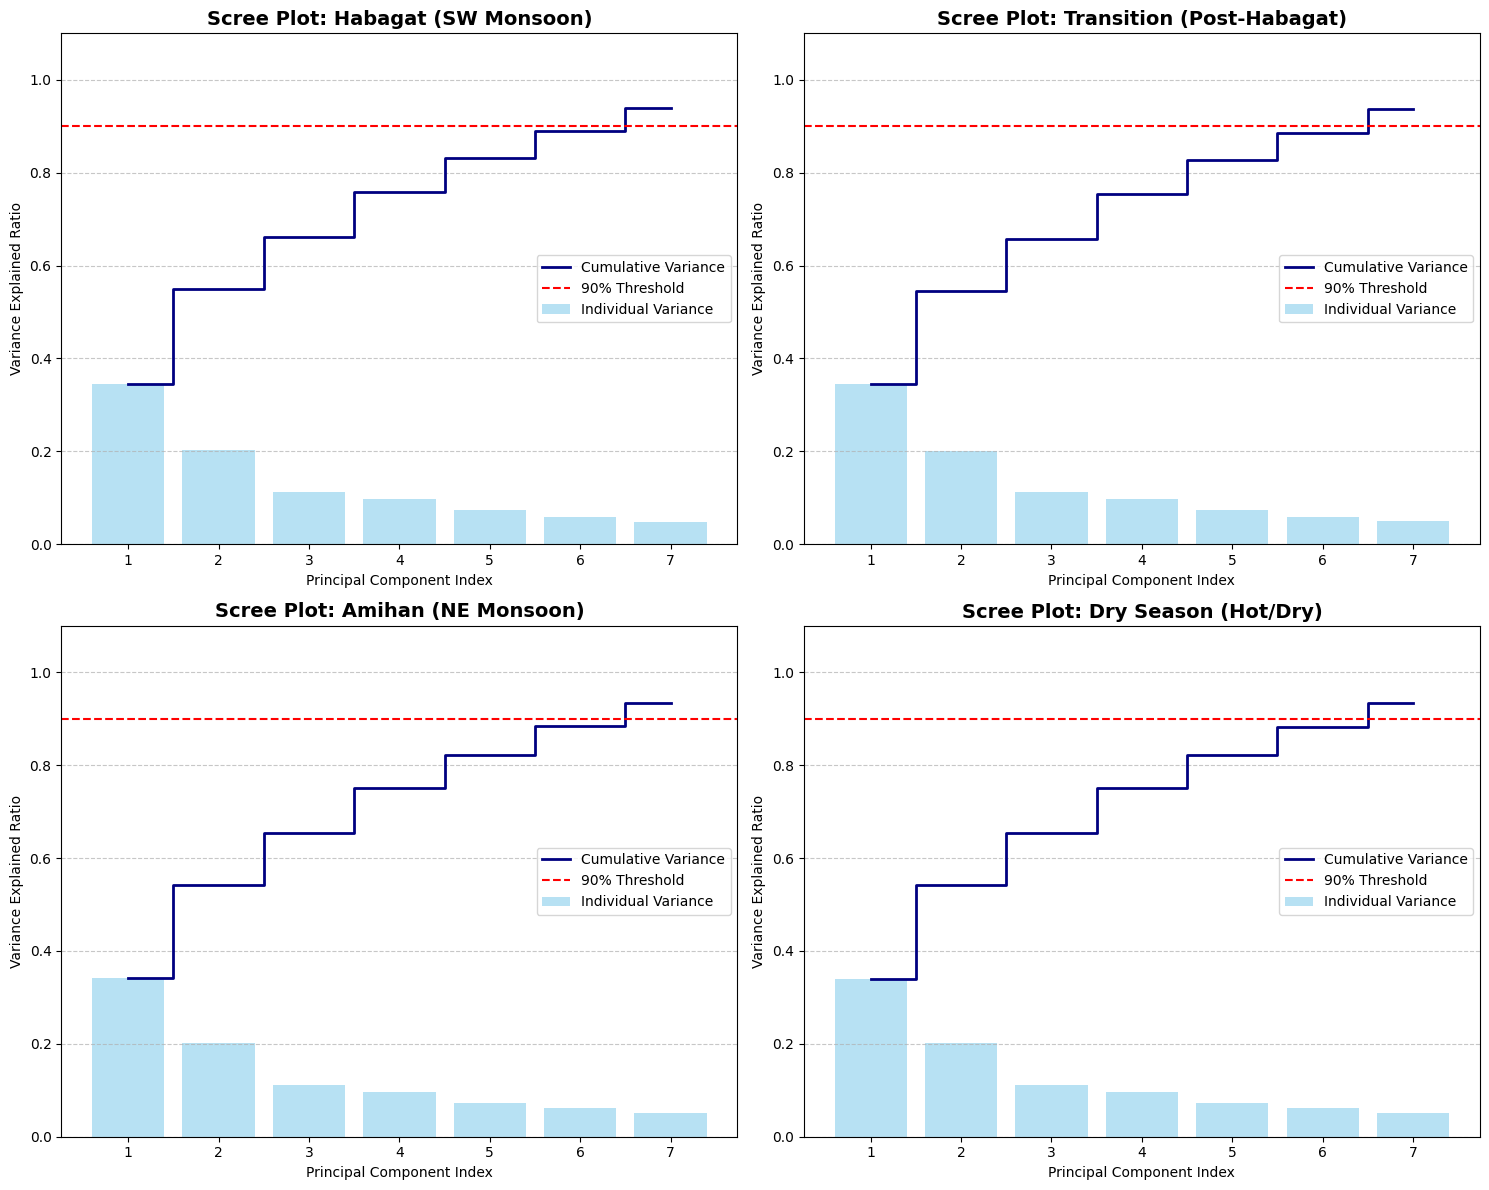

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (season_name, data) in enumerate(processed_folds.items()):
    pca_model = data['pca_model']
    
    # Calculate Individual and Cumulative Variance
    exp_var = pca_model.explained_variance_ratio_
    cum_var = np.cumsum(exp_var)
    n_comp = len(exp_var)
    
    # Plot Bars for Individual Variance
    axes[i].bar(range(1, n_comp + 1), exp_var, alpha=0.6, align='center', 
                label='Individual Variance', color='skyblue')
    
    # Plot Step for Cumulative Variance
    axes[i].step(range(1, n_comp + 1), cum_var, where='mid', 
                 label='Cumulative Variance', color='navy', linewidth=2)
    
    # Add the 90% Threshold Line
    axes[i].axhline(y=0.90, color='red', linestyle='--', label='90% Threshold')
    
    # Formatting the Plot
    axes[i].set_title(f'Scree Plot: {season_name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Principal Component Index')
    axes[i].set_ylabel('Variance Explained Ratio')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xticks(range(1, n_comp + 1))
    axes[i].legend(loc='center right')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

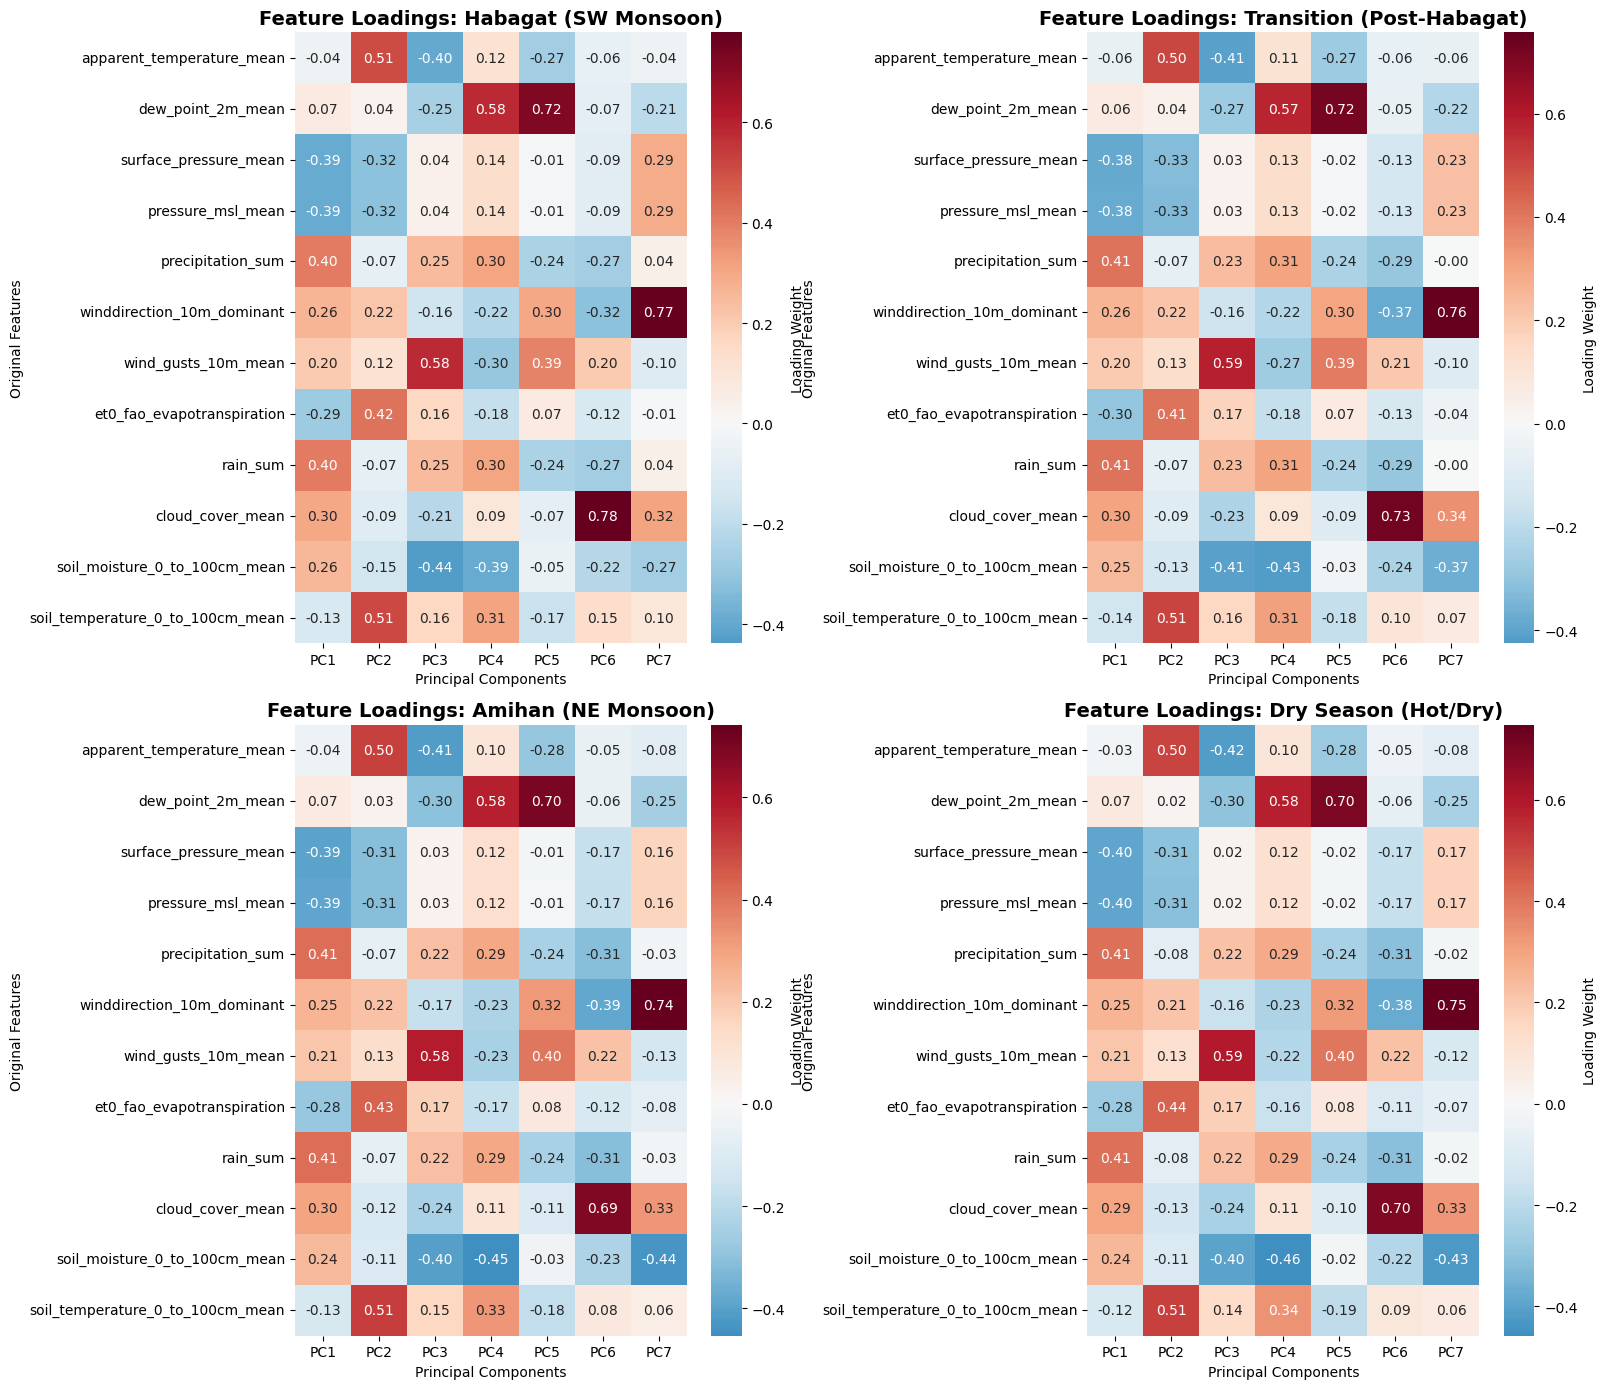

In [54]:
# Set up the visualization grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (season_name, data) in enumerate(processed_folds.items()):
    # Get the loadings dataframe stored earlier
    loadings = data['loadings']
    
    # Focus on the top components
    # Use .iloc[:, :7] to ensure plot the first 7 PCs only
    plot_loadings = loadings.iloc[:, :7]
    
    # Create the Heatmap
    sns.heatmap(plot_loadings, 
                annot=True, 
                cmap='RdBu_r', 
                center=0, 
                fmt='.2f', 
                ax=axes[i],
                cbar_kws={'label': 'Loading Weight'})
    
    # Formatting
    axes[i].set_title(f'Feature Loadings: {season_name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Principal Components')
    axes[i].set_ylabel('Original Features')

plt.tight_layout()
plt.show()

##### PC1: Precipitation - tracks the presence of low-pressure systems, rains, or typhoons.
##### PC2: Thermal Energy - represents the thermodynamic cycle, how hot and energetic the day is.
##### PC3: Mechanical Drying - captures trade-off between wind speed and the cooling effect of soil moisture.
##### PC4: Evaporation - interaction between how much wet the ground is versus how much water the air can hold. 
##### PC5: Air Mass - cares about how much water vapos is currently in the air.
##### PC6: Cloud Cover - cloud cover and blocking of solar radiation.
##### PC7: Directional Bias - tells where the wind is coming from.

# ARIMAX Modeling

In [ ]:
import pmdarima as pm
from sklearn.metrics import mean_absolute_error

In [59]:
# Define the labels
target_labels = ['temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean']

arimax_results = {}

for season, data in processed_folds.items():
    print(f"\n🚀 Fitting ARIMAX for Season: {season}")
    arimax_results[season] = {}
    
    # Exogenous variables
    X_train = data['X_train_pca'][:, :7]
    X_test = data['X_test_pca'][:, :7]
    
    for label in target_labels:
        print(f"   -> Modeling {label}...")
        
        # Target series
        y_train = data['y_train'][label]
        y_test = data['y_test'][label]
        
        # 3. AUTO-ARIMAX (p, d, q)
        model = pm.auto_arima(y=y_train, 
                              X=X_train,
                              seasonal=True,
                              m=7,           # Weekly seasonality (urban heat island)
                              error_action='ignore',  
                              suppress_warnings=True, 
                              stepwise=True)
        
        # Generate 14-Day Forecast
        forecast = model.predict(n_periods=14, X=X_test)
        
        # Evaluate Performance
        mae = mean_absolute_error(y_test, forecast)
        
        # Store
        arimax_results[season][label] = {
            'model': model,
            'params': model.get_params()['order'],
            'seasonal_params': model.get_params()['seasonal_order'],
            'forecast': forecast,
            'actual': y_test.values,
            'mae': mae,
            'rmse': rmse
        }
        
        print(f"      Best Order: {model.get_params()['order']} | MAE: {mae:.2f}")

print("\n✅ All 12 models fitted and tested!")


🚀 Fitting ARIMAX for Season: Habagat (SW Monsoon)
   -> Modeling temperature_2m_mean...


      Best Order: (1, 1, 1) | MAE: 0.51
   -> Modeling relative_humidity_2m_mean...
      Best Order: (1, 1, 2) | MAE: 1.35
   -> Modeling wind_speed_10m_mean...
      Best Order: (2, 1, 2) | MAE: 0.62

🚀 Fitting ARIMAX for Season: Transition (Post-Habagat)
   -> Modeling temperature_2m_mean...
      Best Order: (1, 1, 1) | MAE: 0.24
   -> Modeling relative_humidity_2m_mean...
      Best Order: (1, 1, 2) | MAE: 1.87
   -> Modeling wind_speed_10m_mean...
      Best Order: (2, 1, 2) | MAE: 1.25

🚀 Fitting ARIMAX for Season: Amihan (NE Monsoon)
   -> Modeling temperature_2m_mean...
      Best Order: (1, 1, 1) | MAE: 0.37
   -> Modeling relative_humidity_2m_mean...
      Best Order: (2, 1, 1) | MAE: 4.69
   -> Modeling wind_speed_10m_mean...
      Best Order: (2, 1, 2) | MAE: 0.70

🚀 Fitting ARIMAX for Season: Dry Season (Hot/Dry)
   -> Modeling temperature_2m_mean...
      Best Order: (1, 1, 1) | MAE: 0.56
   -> Modeling relative_humidity_2m_mean...
      Best Order: (2, 1, 1) | MAE: 3.21

In [106]:
all_forecasts = []

for season_name, labels in arimax_results.items():
    for label_name, metrics in labels.items():
        
        # Get the actual and predicted values
        actuals = metrics['actual']
        preds = metrics['forecast']
        
        # Create a sub-dataframe for these 14 days
        df_temp = pd.DataFrame({
            'Season': season_name,
            'Target_Variable': label_name,
            'Day_Ahead': range(1, 15),
            'Actual_Value': actuals,
            'Predicted_Value': preds
        })
        
        # Calculate the Error for each specific day
        df_temp['Absolute_Error'] = abs(df_temp['Actual_Value'] - df_temp['Predicted_Value'])
        
        all_forecasts.append(df_temp)

# Combine everything into one Master DataFrame
results_master_df = pd.concat(all_forecasts, ignore_index=True)
results_master_df = results_master_df.round(3)

print(f"ARIMAX:")
display(results_master_df)

ARIMAX:


,Season,Target_Variable,Day_Ahead,Actual_Value,Predicted_Value,Absolute_Error
0,Habagat (SW Monsoon),temperature_2m_mean,1,25.613001,25.882,0.269
1,Habagat (SW Monsoon),temperature_2m_mean,2,26.691999,26.432,0.260
2,Habagat (SW Monsoon),temperature_2m_mean,3,27.273001,26.678,0.595
3,Habagat (SW Monsoon),temperature_2m_mean,4,27.337000,26.588,0.749
4,Habagat (SW Monsoon),temperature_2m_mean,5,26.242001,25.572,0.670
...,...,...,...,...,...,...
163,Dry Season (Hot/Dry),wind_speed_10m_mean,10,7.709000,8.689,0.979
164,Dry Season (Hot/Dry),wind_speed_10m_mean,11,5.900000,8.120,2.219
165,Dry Season (Hot/Dry),wind_speed_10m_mean,12,4.517000,6.675,2.158
166,Dry Season (Hot/Dry),wind_speed_10m_mean,13,9.268000,11.855,2.587


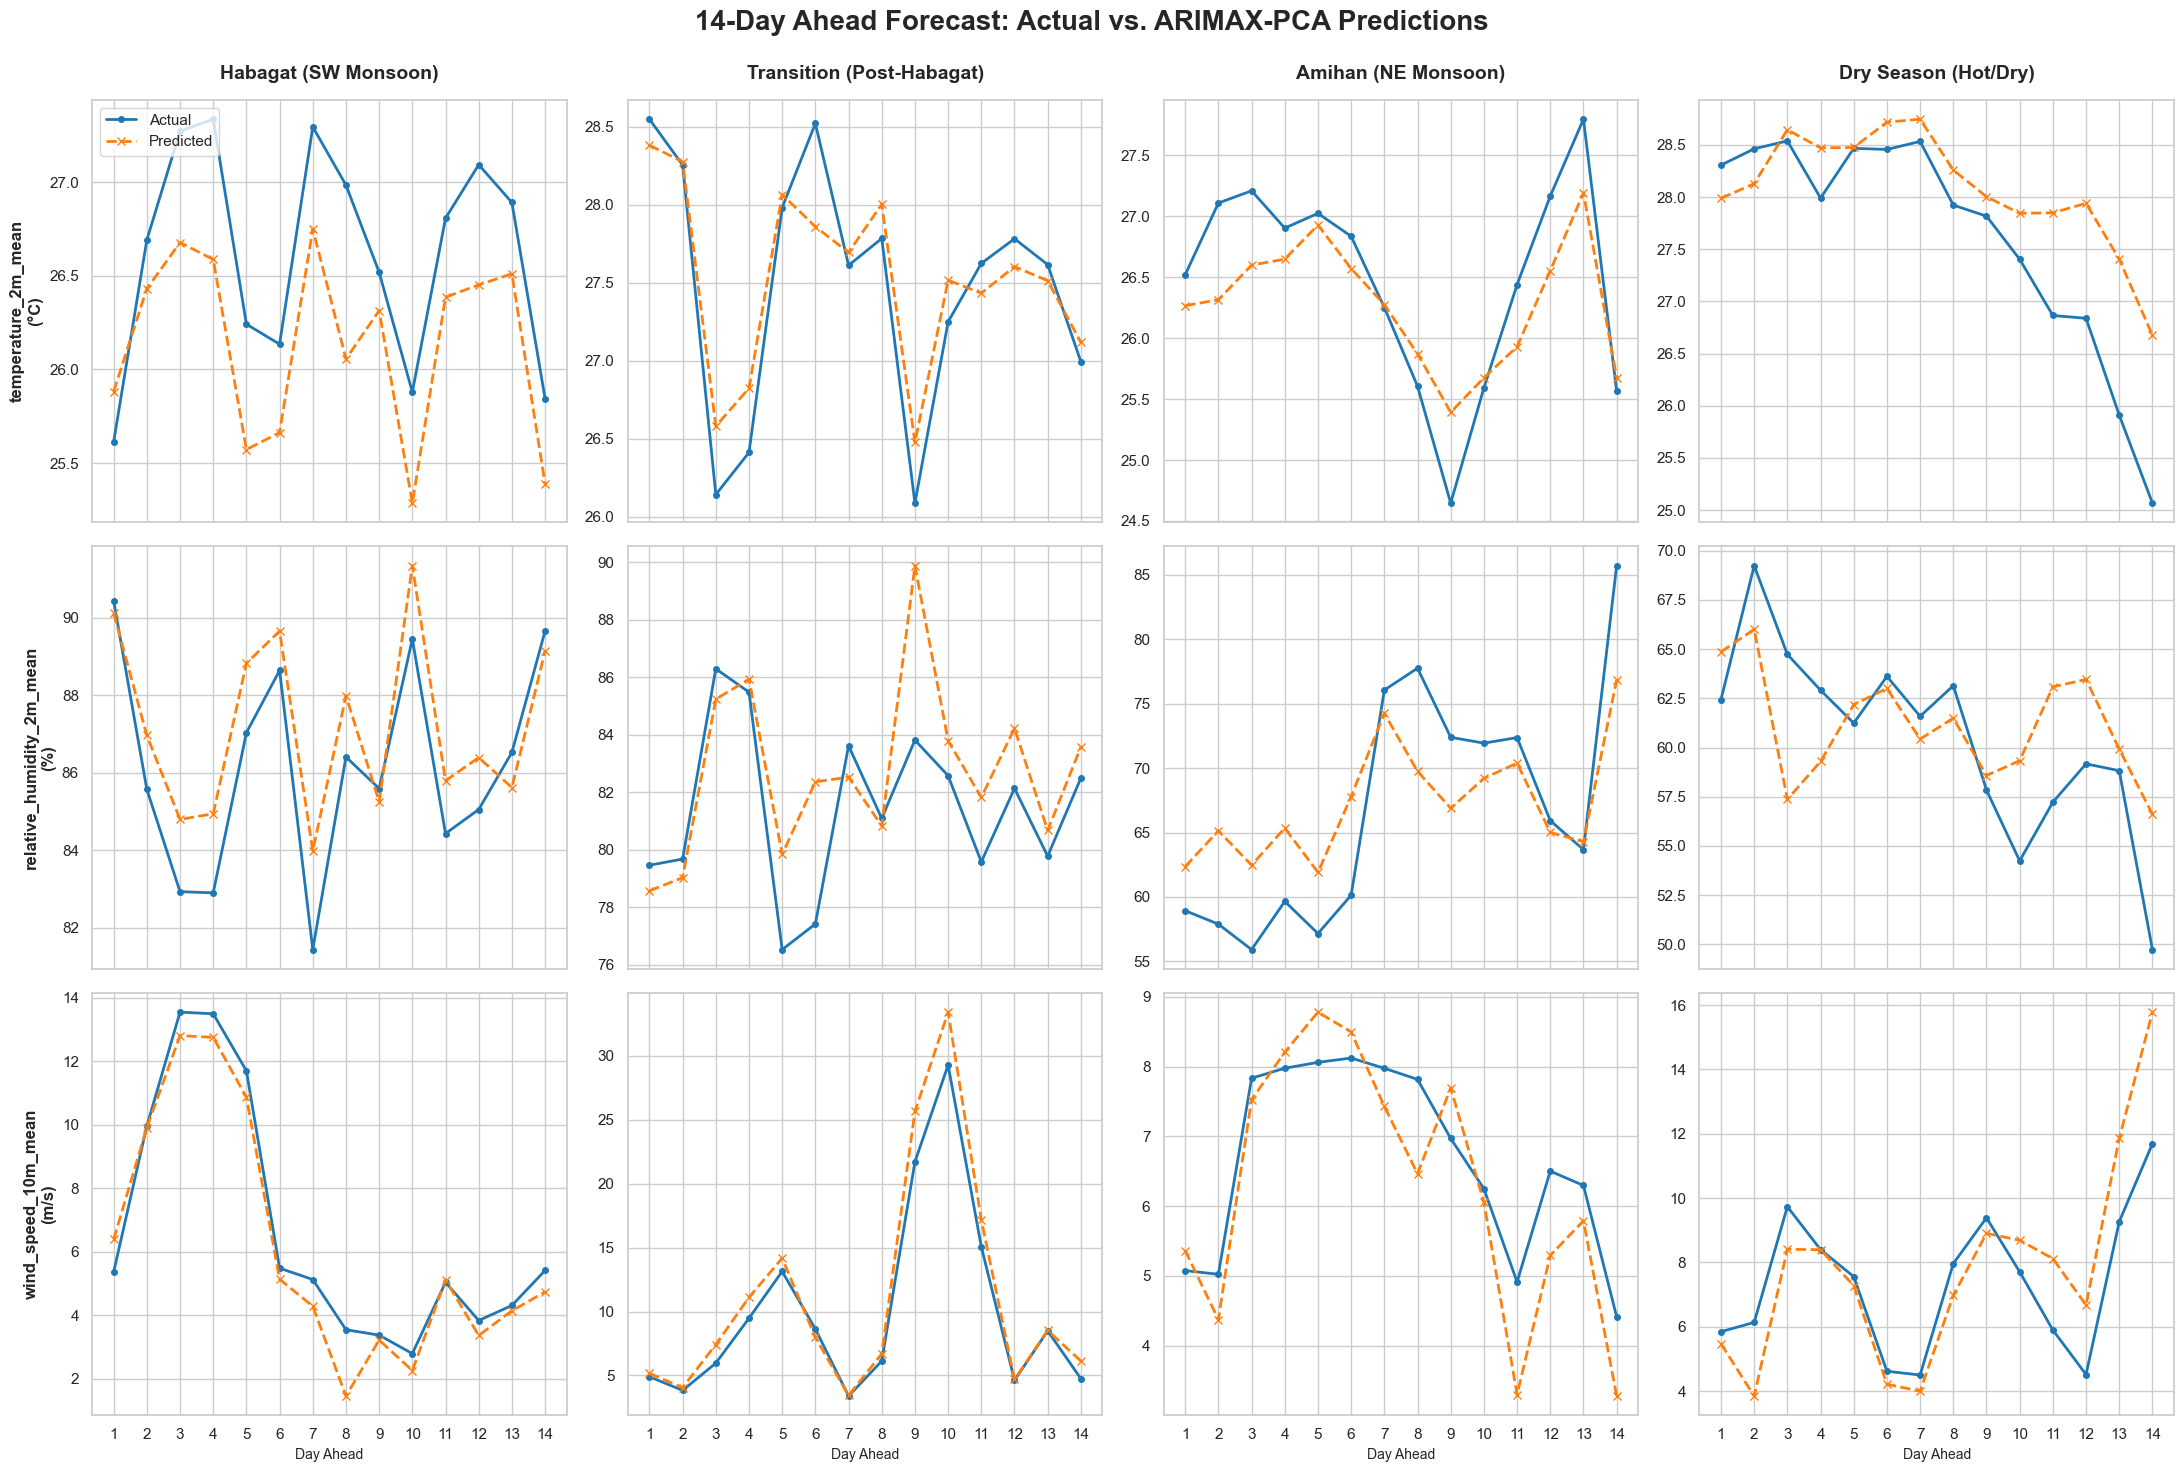

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 4, figsize=(24, 18), sharex=True)

targets = ['temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean']
seasons = [
    'Habagat (SW Monsoon)', 
    'Transition (Post-Habagat)', 
    'Amihan (NE Monsoon)', 
    'Dry Season (Hot/Dry)'
]

for row, target in enumerate(targets):
    for col, season in enumerate(seasons):
        ax = axes[row, col]

        data = results_master_df[(results_master_df['Season'] == season) & 
                                 (results_master_df['Target_Variable'] == target)]
        
        # Plot Actual vs Predicted
        ax.plot(data['Day_Ahead'], data['Actual_Value'], marker='o', label='Actual', 
                color='#1f77b4', linewidth=2, markersize=4)
        ax.plot(data['Day_Ahead'], data['Predicted_Value'], marker='x', label='Predicted', 
                color='#ff7f0e', linestyle='--', linewidth=2, markersize=6)
        
        # Formatting
        if row == 0:
            ax.set_title(f"{season}", fontsize=14, fontweight='bold', pad=15)
        
        if col == 0:
            units = "°C" if "temp" in target else "%" if "humidity" in target else "m/s"
            ax.set_ylabel(f"{target}\n({units})", fontsize=12, fontweight='bold')
        
        ax.set_xticks(range(1, 15))
        if row == 2:
            ax.set_xlabel("Day Ahead", fontsize=10)

        if row == 0 and col == 0:
            ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle('14-Day Ahead Forecast: Actual vs. ARIMAX-PCA Predictions', fontsize=20, fontweight='bold')
plt.show()

### ARMIAX Predictions' Validation

In [69]:
from scipy import stats

In [113]:
def hotellings_t2_test(actual, predicted, alpha_levels=[0.01, 0.05]):
    # Vector of differences
    diff = np.array(actual) - np.array(predicted)
    n = 1 # Testing a single 14-day vector (paired observation)
    p = 14 # Dimensions (14 days)
    
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)

    t_stat, p_val = stats.ttest_1samp(diff, 0)
    
    results = {
        'p_value': p_val,
        'Status_0.01': 'Significant Difference' if p_val < 0.01 else 'Acceptable (No Sig. Diff)',
        'Status_0.05': 'Significant Difference' if p_val < 0.05 else 'Acceptable (No Sig. Diff)'
    }
    return results

hotelling_results = []

for season in results_master_df['Season'].unique():
    for target in results_master_df['Target_Variable'].unique():

        subset = results_master_df[(results_master_df['Season'] == season) & 
                                   (results_master_df['Target_Variable'] == target)]
        
        res = hotellings_t2_test(subset['Actual_Value'], subset['Predicted_Value'])
        
        hotelling_results.append({
            'Season': season,
            'Target': target,
            'p-value': round(res['p_value'], 5),
            'Alpha_0.01': res['Status_0.01'],
            'Alpha_0.05': res['Status_0.05']
        })

hotelling_df = pd.DataFrame(hotelling_results)
print('ARIMAX Evaluation')
display(hotelling_df)

ARIMAX Evaluation


,Season,Target,p-value,Alpha_0.01,Alpha_0.05
0,Habagat (SW Monsoon),temperature_2m_mean,0.00003,Significant Difference,Significant Difference
1,Habagat (SW Monsoon),relative_humidity_2m_mean,0.00339,Significant Difference,Significant Difference
2,Habagat (SW Monsoon),wind_speed_10m_mean,0.02318,Acceptable (No Sig. Diff),Significant Difference
3,Transition (Post-Habagat),temperature_2m_mean,0.52390,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
4,Transition (Post-Habagat),relative_humidity_2m_mean,0.04674,Acceptable (No Sig. Diff),Significant Difference
5,Transition (Post-Habagat),wind_speed_10m_mean,0.00993,Significant Difference,Significant Difference
6,Amihan (NE Monsoon),temperature_2m_mean,0.10259,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
7,Amihan (NE Monsoon),relative_humidity_2m_mean,0.77453,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
8,Amihan (NE Monsoon),wind_speed_10m_mean,0.09538,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
9,Dry Season (Hot/Dry),temperature_2m_mean,0.01288,Acceptable (No Sig. Diff),Significant Difference


In [118]:
arimax_rmse_results = []

for season in results_master_df['Season'].unique():
    for target in results_master_df['Target_Variable'].unique():
        
        subset = results_master_df[(results_master_df['Season'] == season) & 
                                   (results_master_df['Target_Variable'] == target)]
        
        actual = subset['Actual_Value']
        pred = subset['Predicted_Value']
        
        rmse = np.sqrt(np.mean((actual - pred)**2))
        
        arimax_rmse_results.append({
            'Season': season,
            'Target': target,
            'RMSE': round(rmse, 4)
        })

arimax_rmse_df = pd.DataFrame(arimax_rmse_results)

print("ARIMAX RMSE Performance")
display(arimax_rmse_df)

ARIMAX RMSE Performance


,Season,Target,RMSE
0,Habagat (SW Monsoon),temperature_2m_mean,0.5492
1,Habagat (SW Monsoon),relative_humidity_2m_mean,1.4973
2,Habagat (SW Monsoon),wind_speed_10m_mean,0.8045
3,Transition (Post-Habagat),temperature_2m_mean,0.2937
4,Transition (Post-Habagat),relative_humidity_2m_mean,2.5179
5,Transition (Post-Habagat),wind_speed_10m_mean,1.8051
6,Amihan (NE Monsoon),temperature_2m_mean,0.4519
7,Amihan (NE Monsoon),relative_humidity_2m_mean,5.4028
8,Amihan (NE Monsoon),wind_speed_10m_mean,0.8284
9,Dry Season (Hot/Dry),temperature_2m_mean,0.7519


# Laggged Multiple Linear Regression

### Partial Auto-Correlation Function Plots

In [75]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

Diagnostic for Habagat (SW Monsoon)...


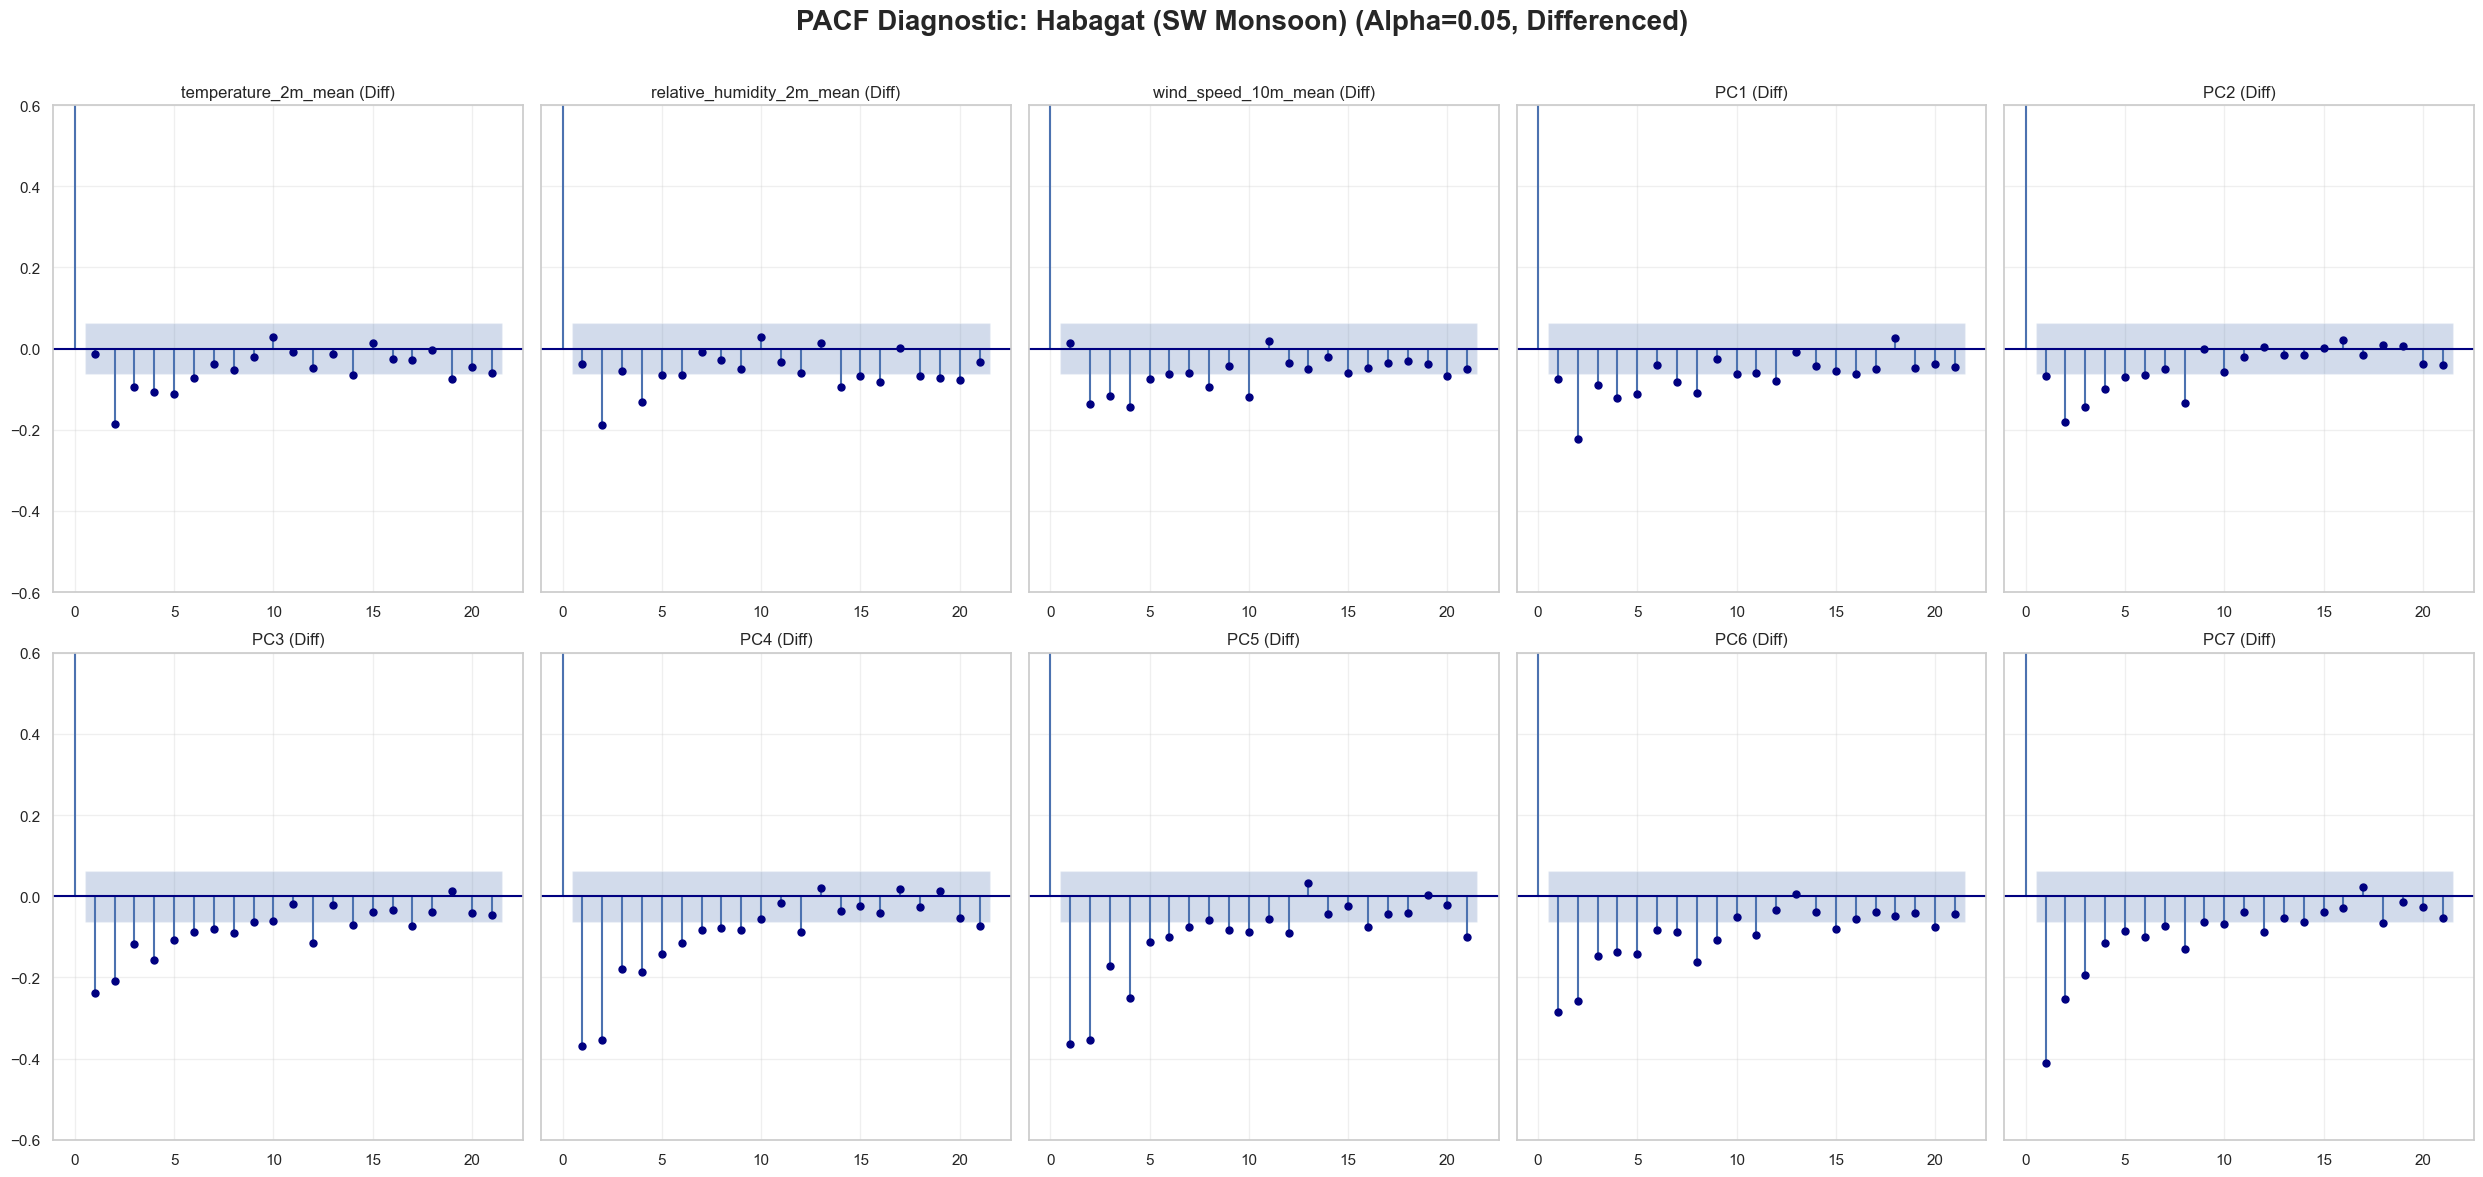

Diagnostic for Transition (Post-Habagat)...


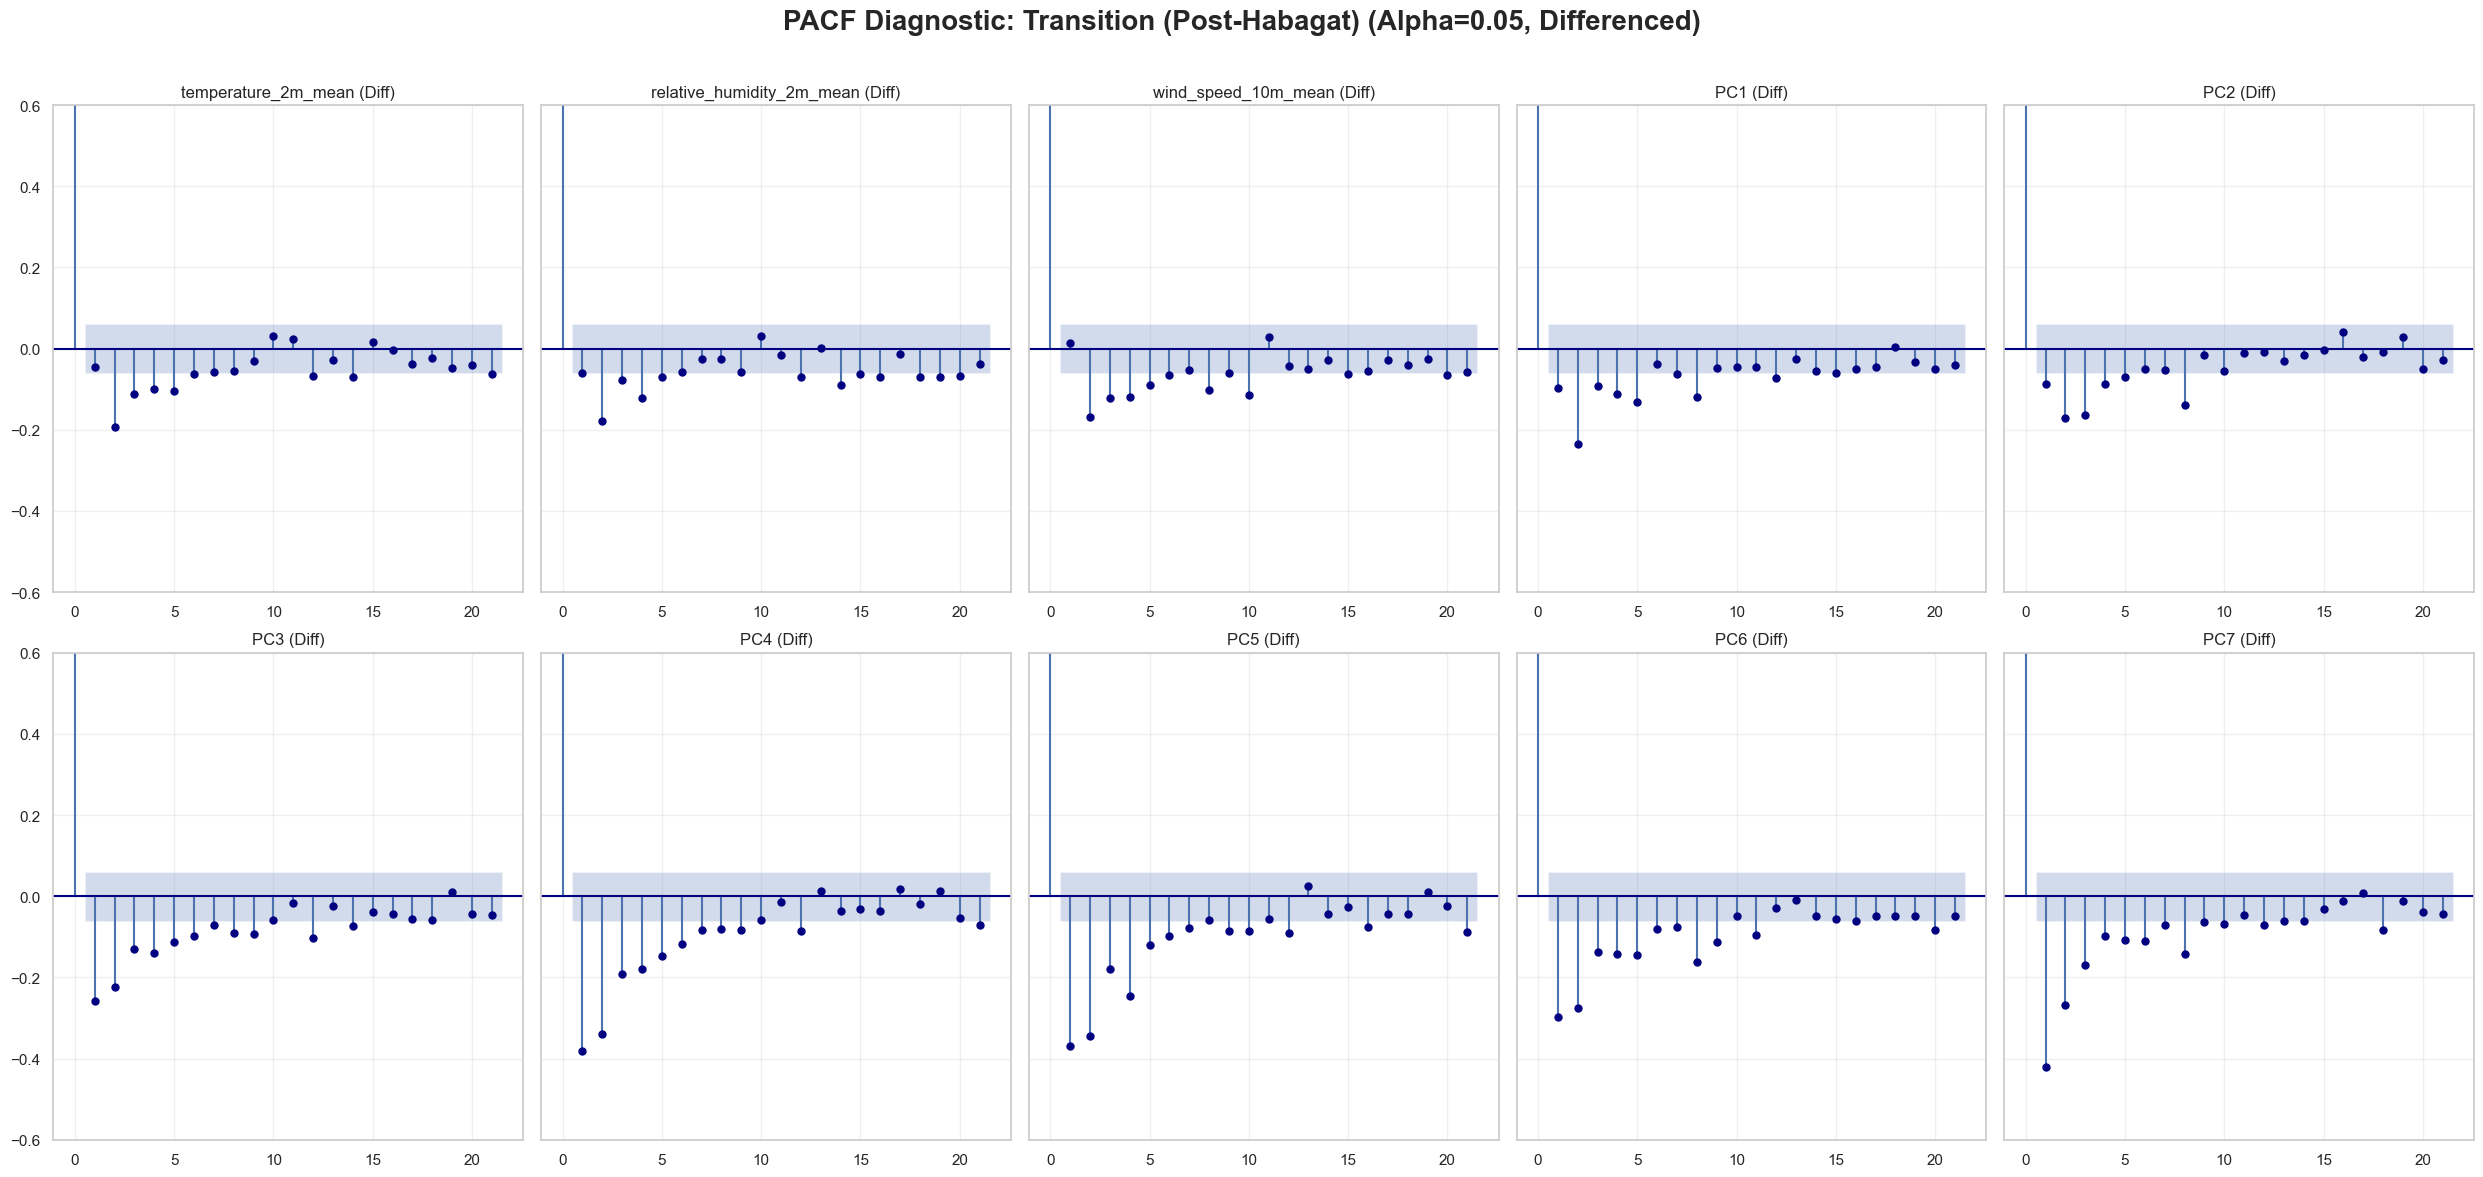

Diagnostic for Amihan (NE Monsoon)...


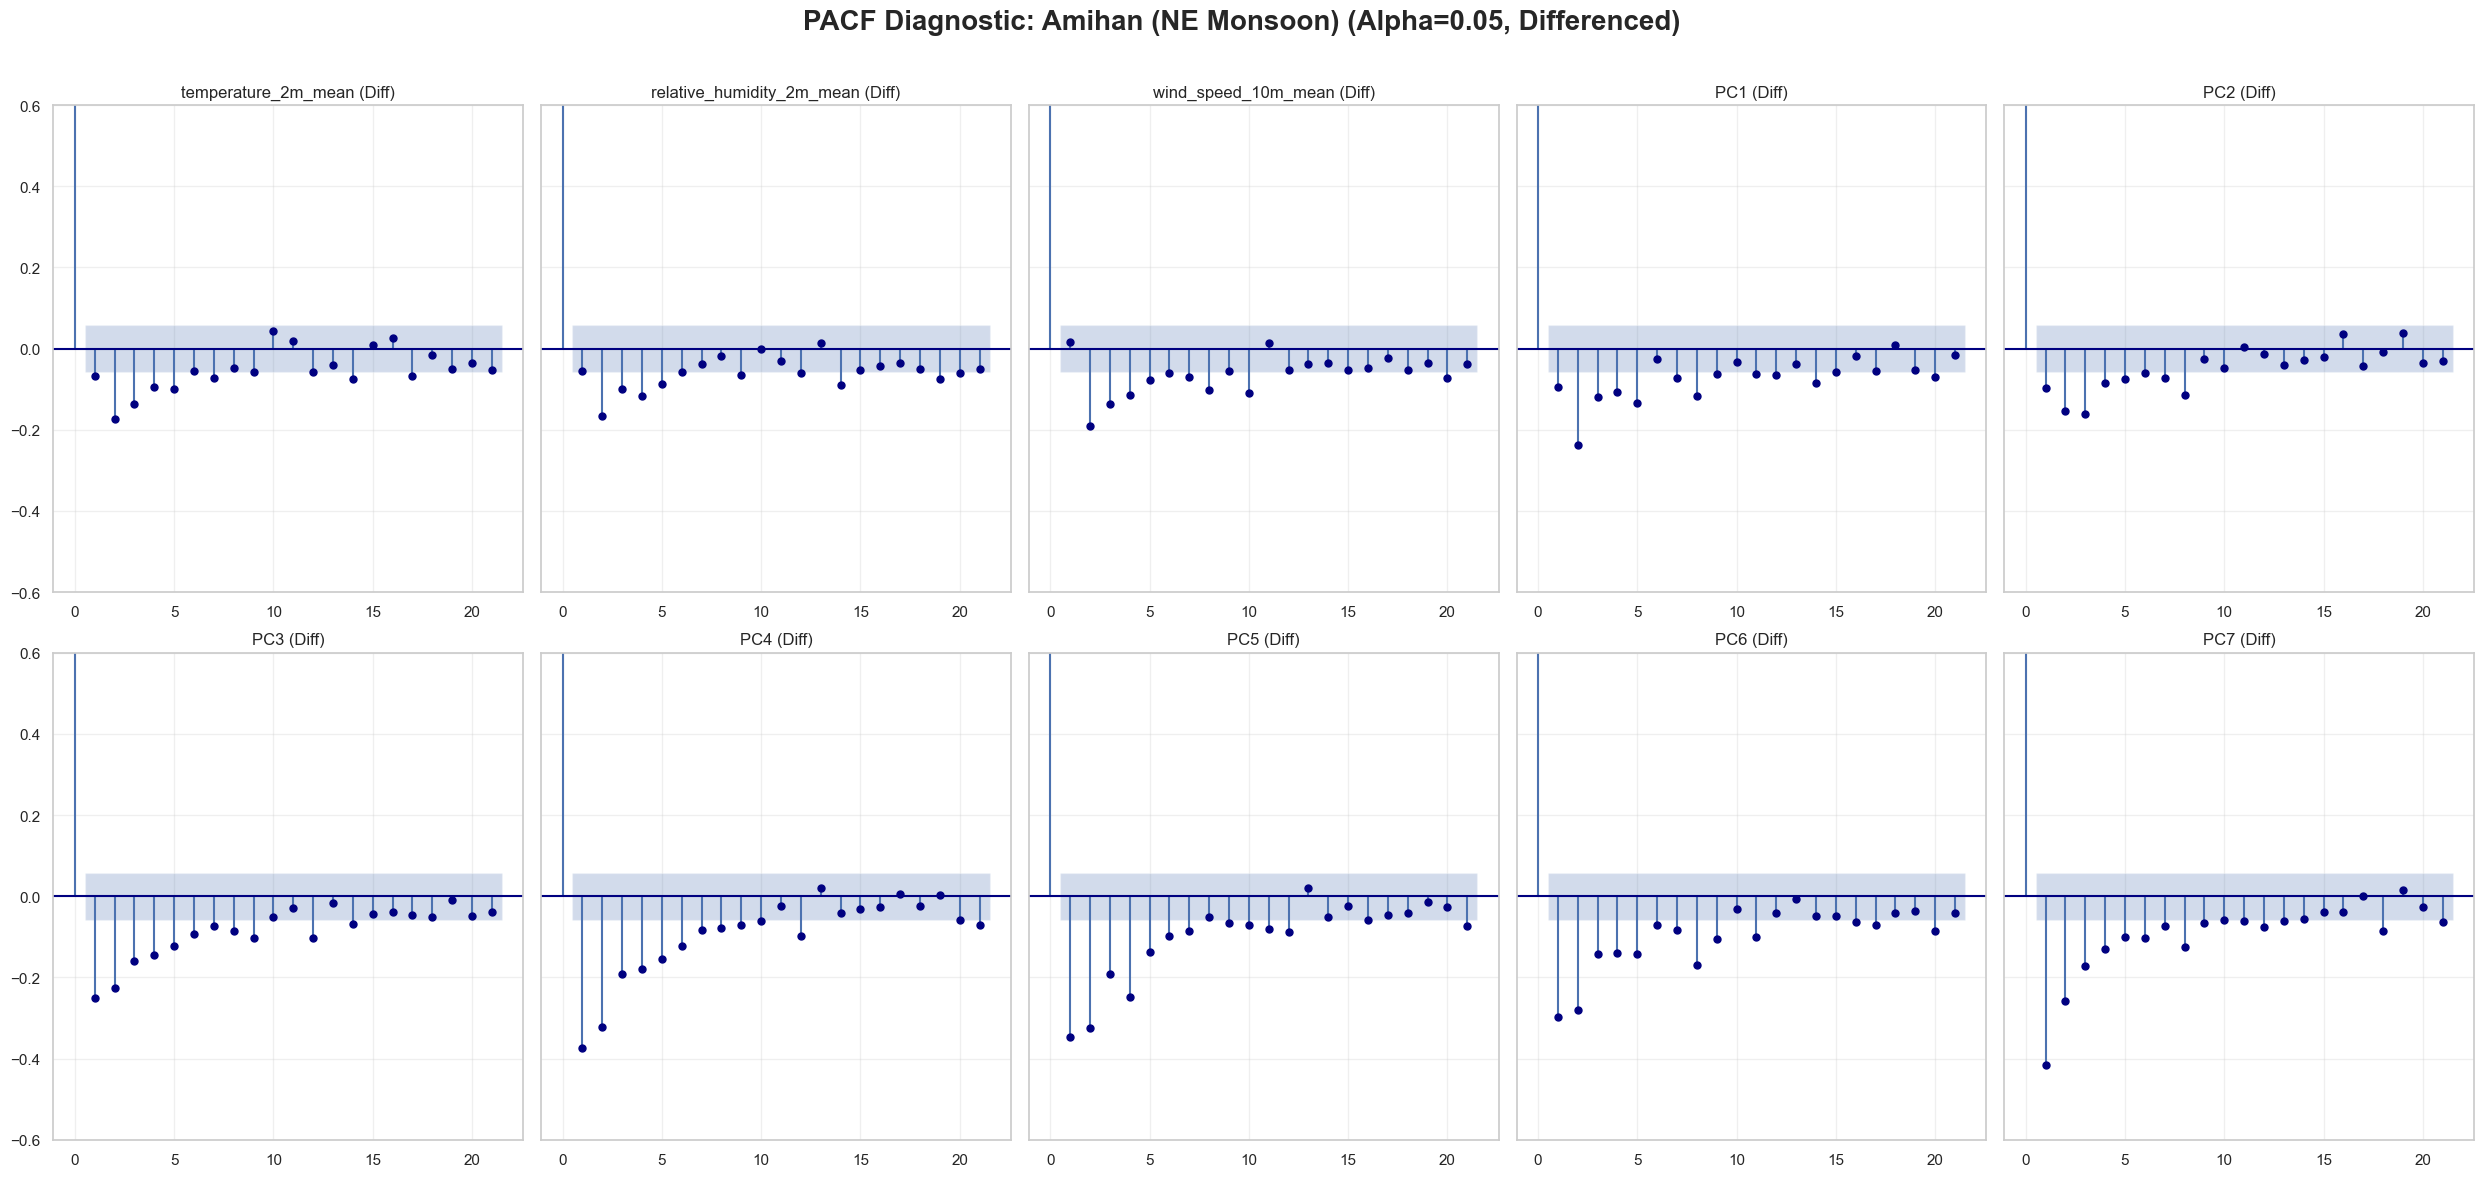

Diagnostic for Dry Season (Hot/Dry)...


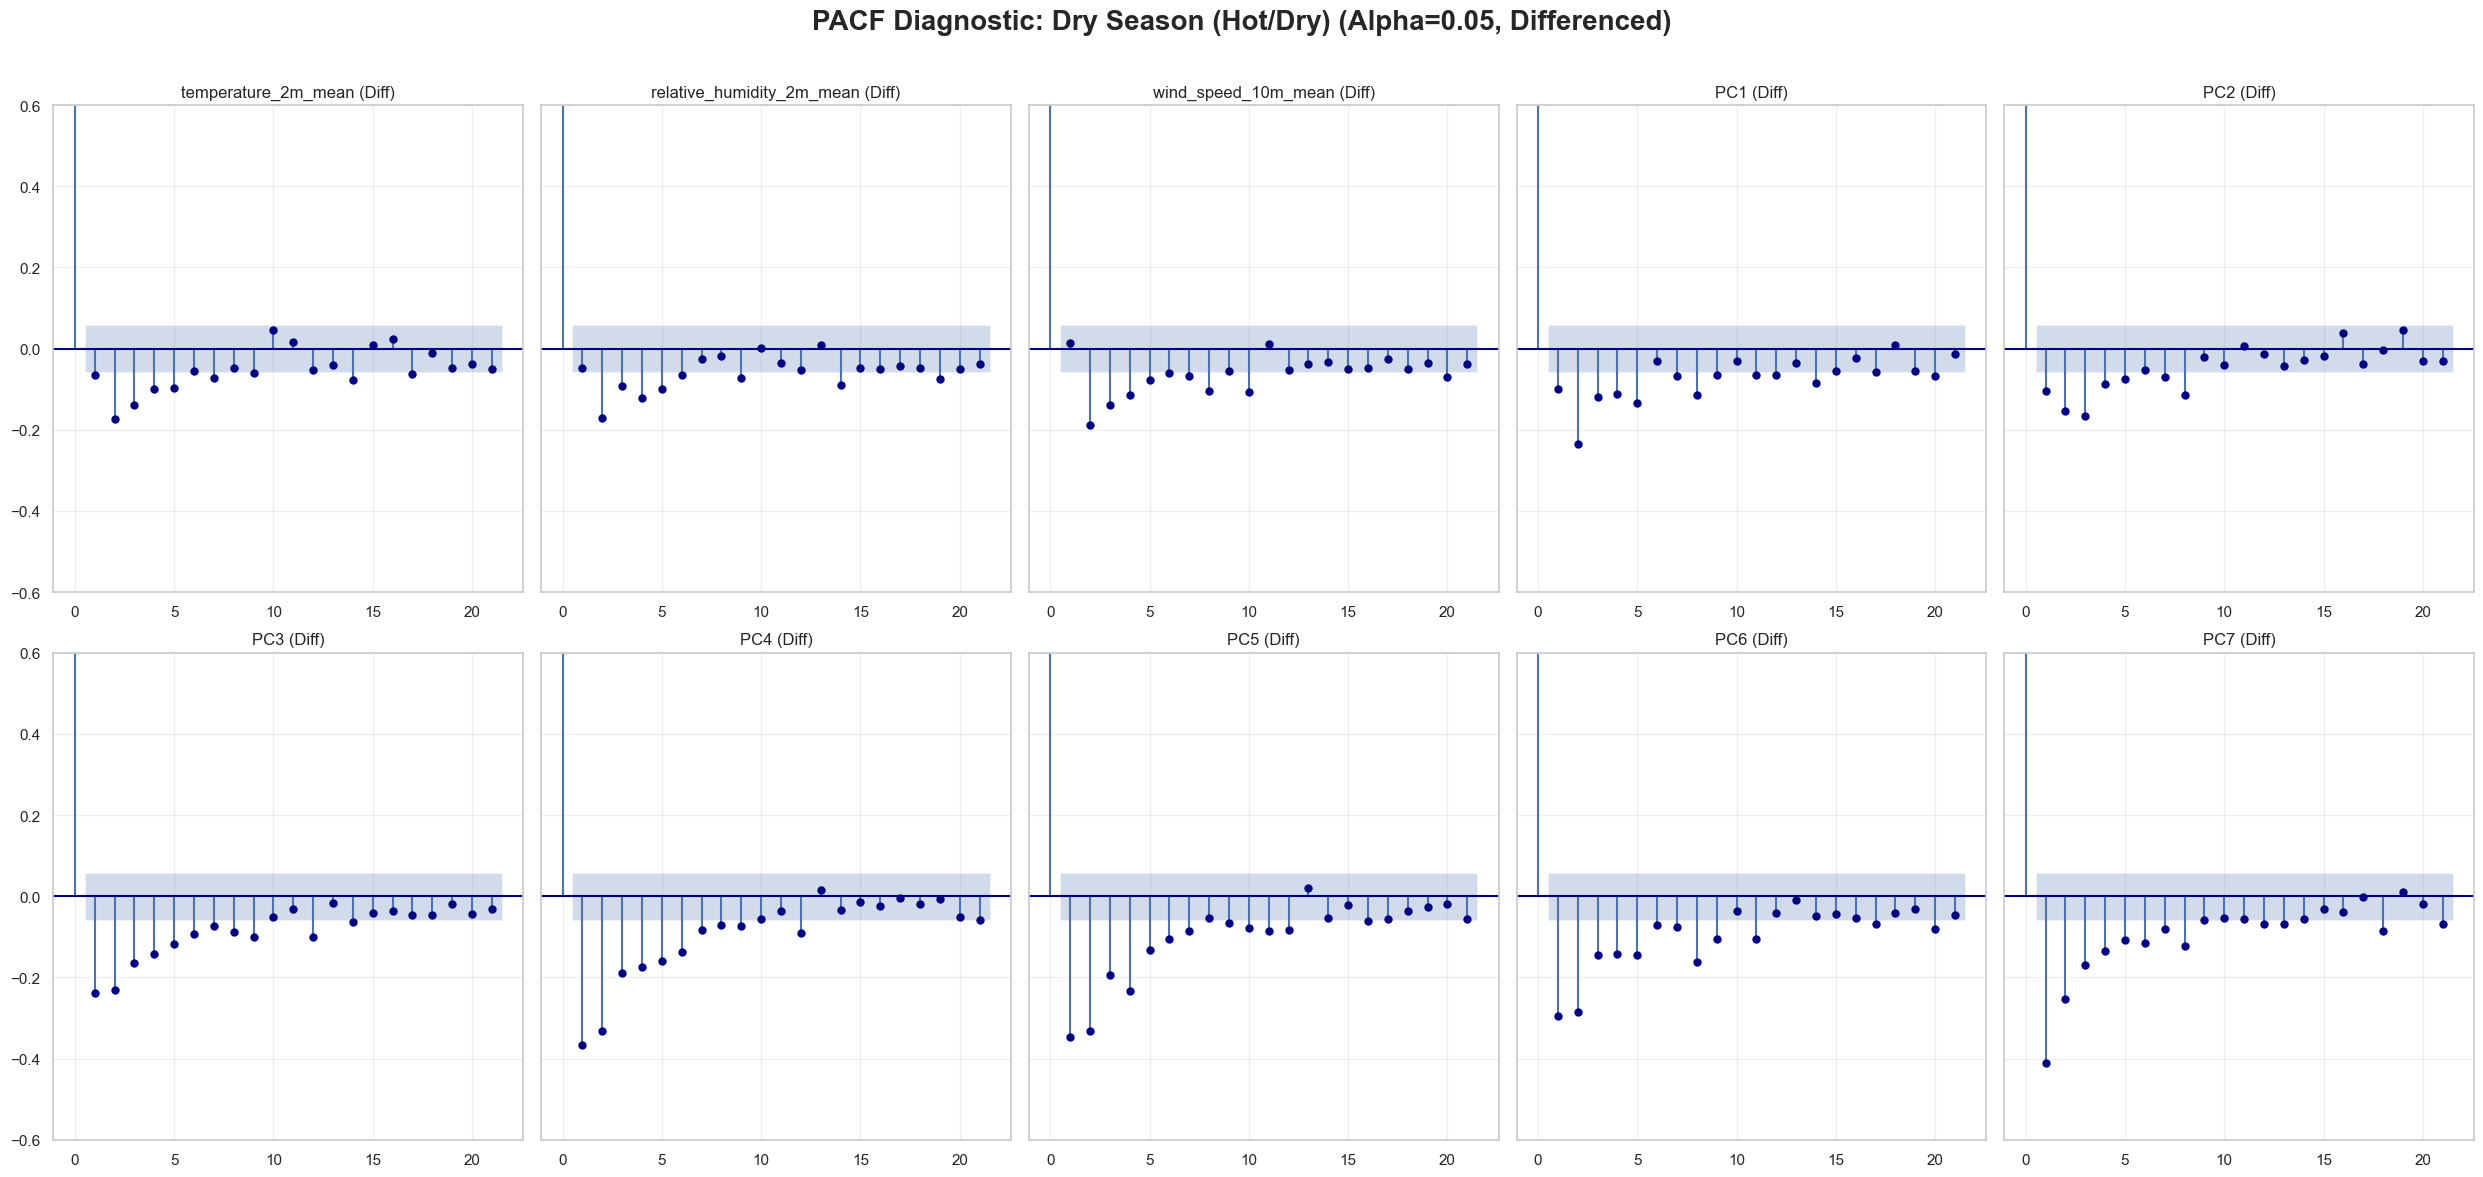

In [82]:
target_labels = ['temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean']
pc_names = [f'PC{i+1}' for i in range(7)]
diagnostics = target_labels + pc_names

def plot_robust_pacf(fold_name):
    fig, axes = plt.subplots(2, 5, figsize=(25, 12), sharey=True)
    axes = axes.flatten()
    
    print(f"Diagnostic for {fold_name}...")
    
    fold_data = processed_folds[fold_name]

    df_diag = pd.DataFrame(fold_data['X_train_pca'][:, :7], columns=pc_names)
    for label in target_labels:
        df_diag[label] = fold_data['y_train'][label].values

    for i, col in enumerate(diagnostics):
        series_diff = df_diag[col].diff().dropna()
        
        plot_pacf(series_diff, lags=21, ax=axes[i], alpha=0.05, 
                  title=f'{col} (Diff)', color='navy', method='ywm')
        
        axes[i].set_ylim(-0.6, 0.6)
        axes[i].grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.suptitle(f"PACF Diagnostic: {fold_name} (Alpha=0.05, Differenced)", fontsize=20, fontweight='bold')
    plt.show()

for fold in processed_folds.keys():
    plot_robust_pacf(fold)

### Lagged MLR Modeling

In [95]:
from sklearn.linear_model import LinearRegression

In [94]:
PC_W = 3    # PCs 3 days lag
LABEL_W = 1 # labels 1 day lag

lagged_folds = {}

for season, data in processed_folds.items():
    print(f"Lagged Matrix for: {season}")

    pc_cols = [f'PC{i+1}' for i in range(7)]
    df_pca = pd.DataFrame(data['X_train_pca'][:, :7], columns=pc_cols)
    
    target_labels = ['temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean']
    df_targets = data['y_train'].reset_index(drop=True)

    df_pc_lags = df_pca.copy()
    for col in pc_cols:
        for lag in range(1, PC_W + 1):
            df_pc_lags[f'{col}_lag{lag}'] = df_pca[col].shift(lag)

    df_label_lags = pd.DataFrame()
    for col in target_labels:
        df_label_lags[f'{col}_lag1'] = df_targets[col].shift(1)

    df_final = pd.concat([df_pc_lags, df_label_lags, df_targets], axis=1)

    df_final = df_final.dropna().reset_index(drop=True)

    y_lagged = df_final[target_labels]

    X_lagged = df_final.drop(columns=target_labels)
    
    lagged_folds[season] = {
        'X_train': X_lagged,
        'y_train': y_lagged,
        'feature_names': X_lagged.columns.tolist()
    }
    
    print(f"    Feature Space: {X_lagged.shape[1]} variables | Rows: {X_lagged.shape[0]}")

Lagged Matrix for: Habagat (SW Monsoon)
    Feature Space: 31 variables | Rows: 970
Lagged Matrix for: Transition (Post-Habagat)
    Feature Space: 31 variables | Rows: 1031
Lagged Matrix for: Amihan (NE Monsoon)
    Feature Space: 31 variables | Rows: 1123
Lagged Matrix for: Dry Season (Hot/Dry)
    Feature Space: 31 variables | Rows: 1151


In [100]:
horizons = range(1, 15)  # 1 to 14 days ahead
target_labels = ['temperature_2m_mean', 'relative_humidity_2m_mean', 'wind_speed_10m_mean']
direct_mlr_results = {}

for season, data in lagged_folds.items():
    direct_mlr_results[season] = {}

    X_train_base = data['X_train']
    y_train_base = data['y_train']
    
    for label in target_labels:
        direct_mlr_results[season][label] = {}
        
        for h in horizons:
            # To predict t+h using features at t, shift the target backwards by h
            # This aligns X[t] with y[t+h]
            y_h = y_train_base[label].shift(-h).dropna()
            X_h = X_train_base.iloc[:len(y_h)]

            model_h = LinearRegression()
            model_h.fit(X_h, y_h)
            
            direct_mlr_results[season][label][h] = model_h

mlr_forecast_list = []

for season in lagged_folds.keys():
    # This row contains the PC lags and Label lags for the day right before the test set starts
    X_latest = lagged_folds[season]['X_train'].iloc[-1:] 
    
    # Get the Actual Test Values from original processed_folds
    y_actuals = processed_folds[season]['y_test']
    
    for label in target_labels:
        preds = []
        # Use each of the 14 models (h=1 to 14) on that same 'latest' row
        for h in range(1, 15):
            model = direct_mlr_results[season][label][h]
            prediction = model.predict(X_latest)[0]
            preds.append(prediction)
            
        # Store the 14-day results for comparison
        df_temp = pd.DataFrame({
            'Season': season,
            'Target_Variable': label,
            'Day_Ahead': list(range(1, 15)),
            'Actual_Value': y_actuals[label].values[:14],
            'Predicted_Value': preds,
            'Model_Type': 'Direct_MLR'
        })
        mlr_forecast_list.append(df_temp)

mlr_results_df = pd.concat(mlr_forecast_list, ignore_index=True)

In [105]:
mlr_results_df['Absolute_Error'] = abs(mlr_results_df['Actual_Value'] - mlr_results_df['Predicted_Value'])

mlr_results_master_df = mlr_results_df[[
    'Season', 
    'Target_Variable', 
    'Day_Ahead', 
    'Actual_Value', 
    'Predicted_Value', 
    'Absolute_Error'
]]

mlr_results_master_df = mlr_results_master_df.round(4)

print('Lagged MLR:')
display(mlr_results_master_df)

Lagged MLR:


,Season,Target_Variable,Day_Ahead,Actual_Value,Predicted_Value,Absolute_Error
0,Habagat (SW Monsoon),temperature_2m_mean,1,25.612499,26.542801,0.9303
1,Habagat (SW Monsoon),temperature_2m_mean,2,26.691700,26.548500,0.1431
2,Habagat (SW Monsoon),temperature_2m_mean,3,27.272900,26.755199,0.5177
3,Habagat (SW Monsoon),temperature_2m_mean,4,27.337500,26.844200,0.4933
4,Habagat (SW Monsoon),temperature_2m_mean,5,26.241699,26.947599,0.7059
...,...,...,...,...,...,...
163,Dry Season (Hot/Dry),wind_speed_10m_mean,10,7.709200,9.519000,1.8098
164,Dry Season (Hot/Dry),wind_speed_10m_mean,11,5.900300,8.939000,3.0387
165,Dry Season (Hot/Dry),wind_speed_10m_mean,12,4.517400,8.731800,4.2144
166,Dry Season (Hot/Dry),wind_speed_10m_mean,13,9.267900,8.763900,0.5040


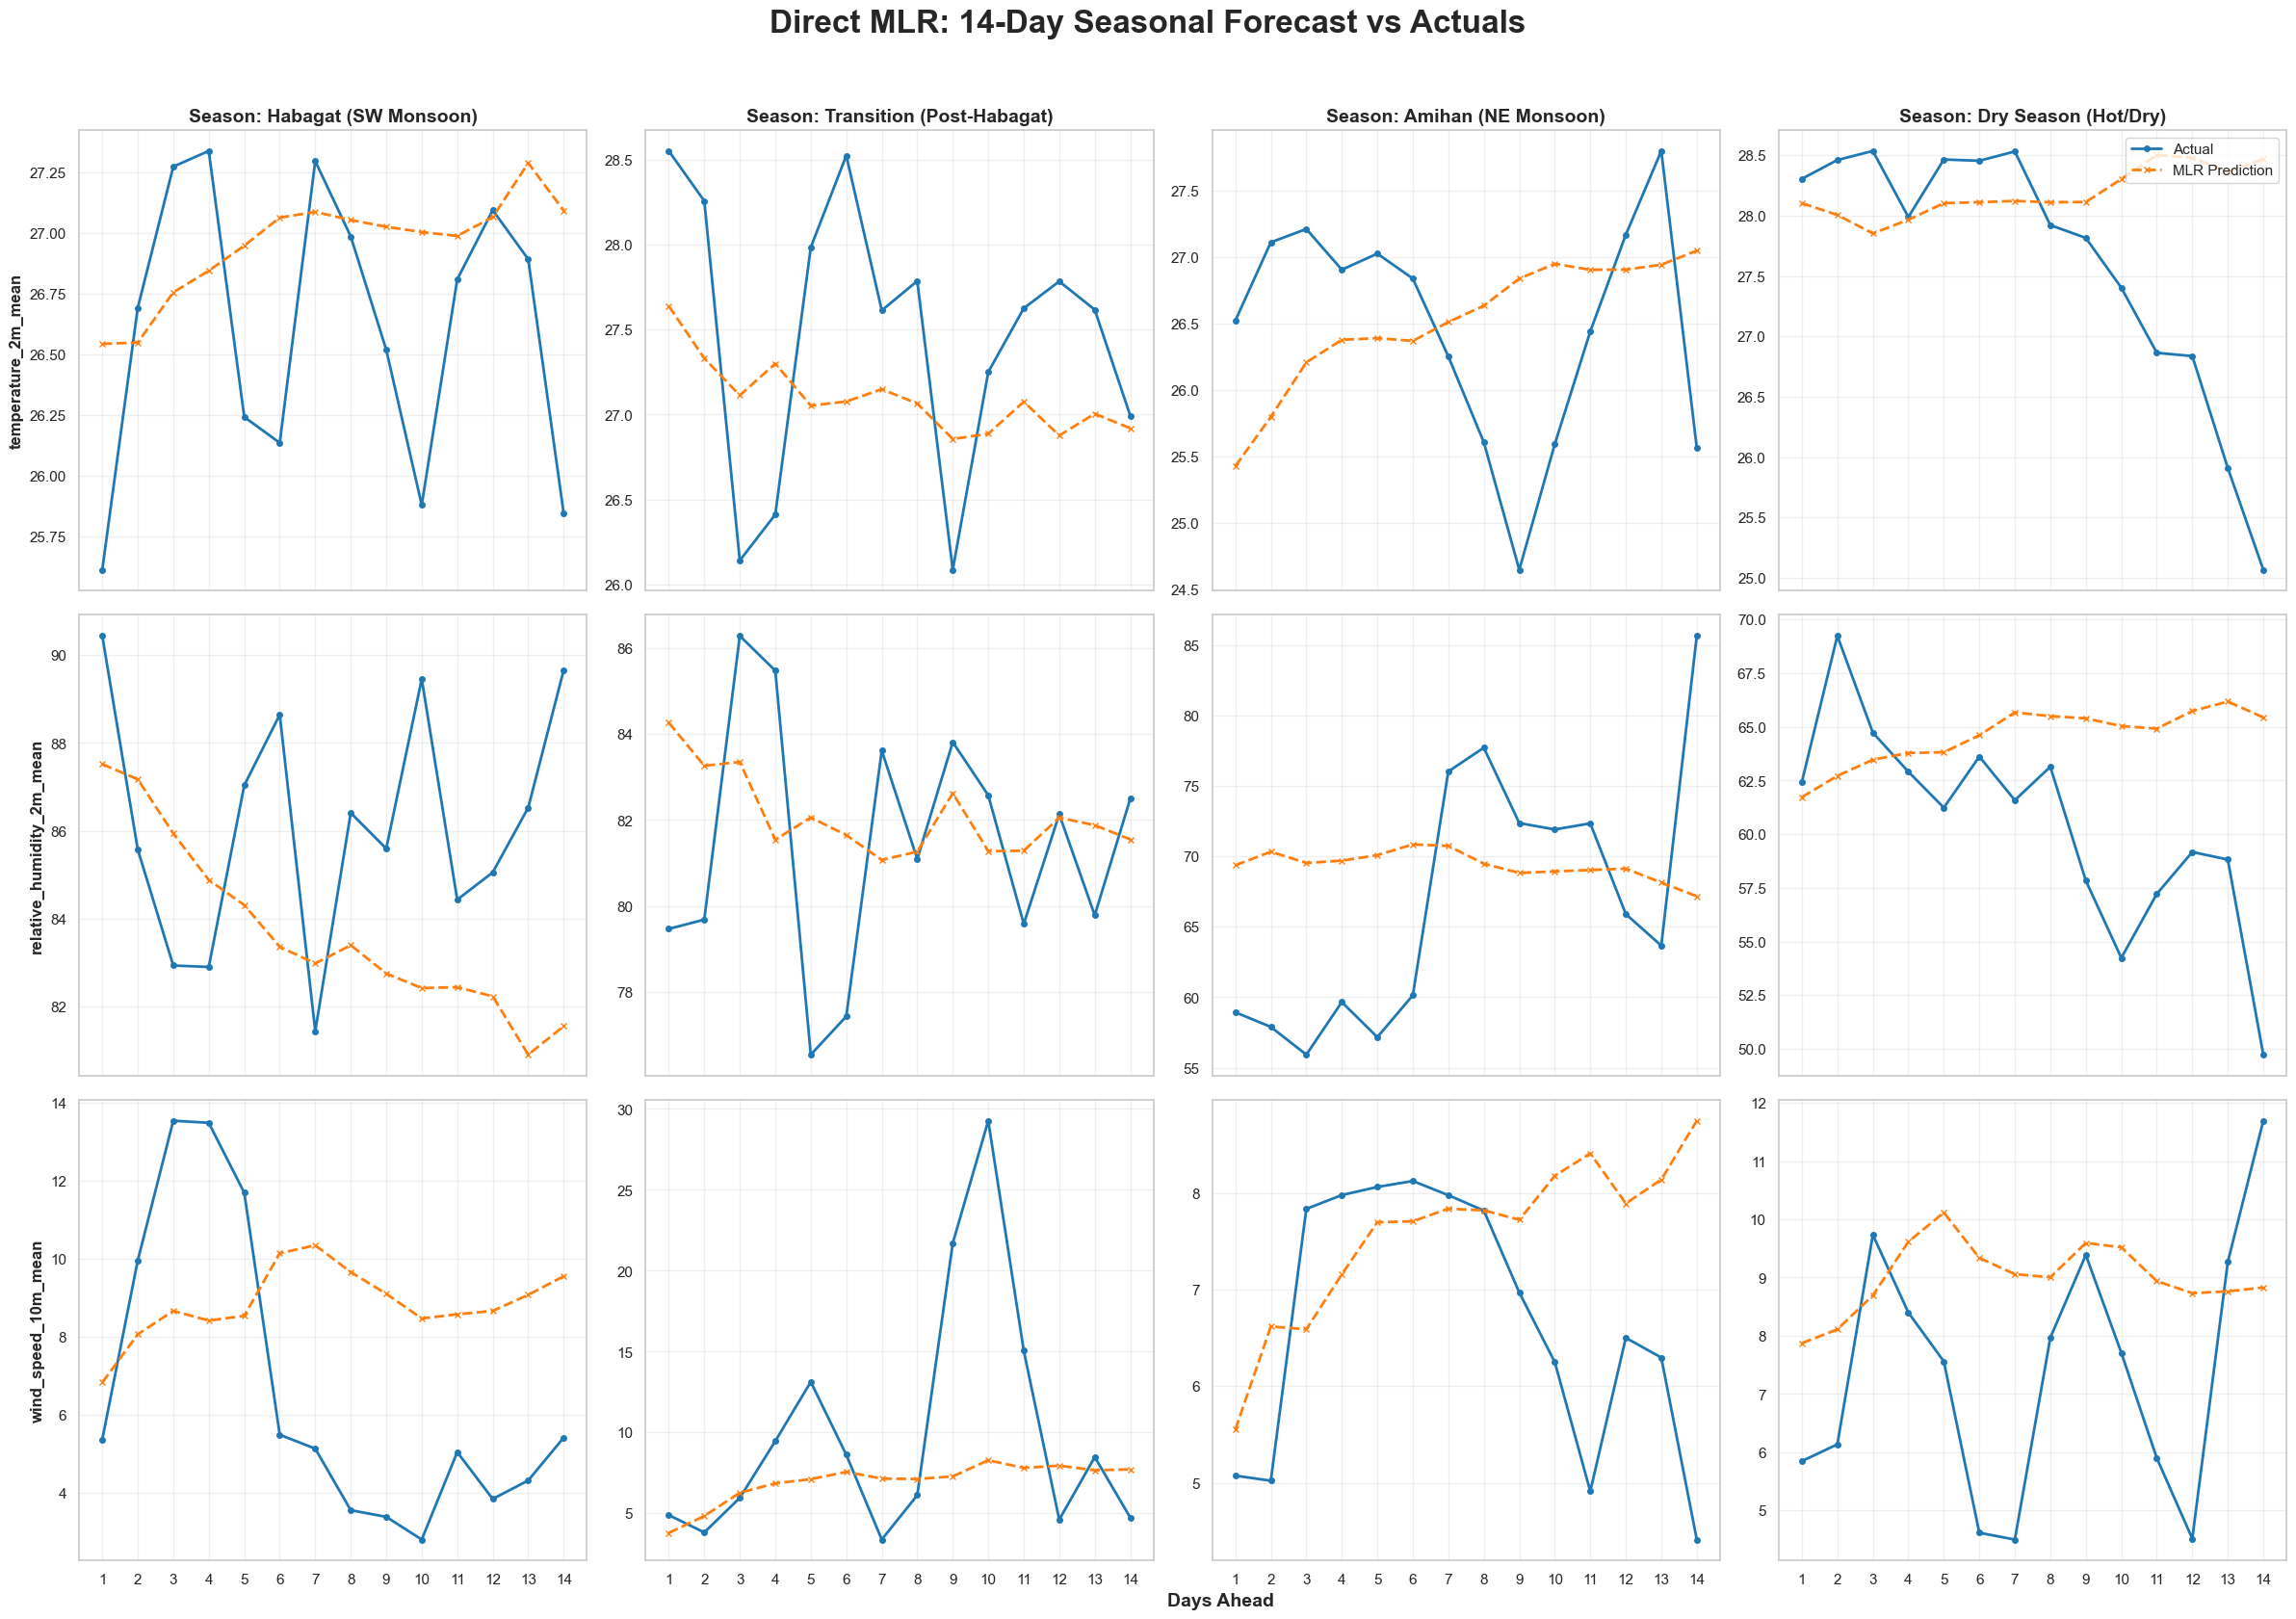

In [110]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 4, figsize=(24, 18), sharex=True)
fig.suptitle('Direct MLR: 14-Day Seasonal Forecast vs Actuals', fontsize=24, fontweight='bold', y=0.95)

seasons = mlr_results_master_df['Season'].unique()
labels = mlr_results_master_df['Target_Variable'].unique()

for i, label in enumerate(labels):
    for j, season in enumerate(seasons):
        subset = mlr_results_master_df[(mlr_results_master_df['Season'] == season) & 
                                       (mlr_results_master_df['Target_Variable'] == label)]
        
        ax = axes[i, j]
        
        ax.plot(subset['Day_Ahead'], subset['Actual_Value'], 
                label='Actual', color='#1f77b4', linewidth=2, marker='o', markersize=4)
        
        ax.plot(subset['Day_Ahead'], subset['Predicted_Value'], 
                label='MLR Prediction', color='#ff7f0e', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        if i == 0: ax.set_title(f"Season: {season}", fontsize=14, fontweight='bold')
        if j == 0: ax.set_ylabel(f"{label}", fontsize=12, fontweight='bold')
        
        ax.set_xticks(range(1, 15))
        ax.grid(True, alpha=0.3)
        
        if i == 0 and j == 3:
            ax.legend(loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.xlabel('Days Ahead', fontsize=14, fontweight='bold', x=-1.1) 
plt.show()

### Lagged MLR Predictions' Validation (Hotelling's Paired Test)

In [114]:
def mlr_hotellings_diagnostic(actual, predicted):
    diff = np.array(actual) - np.array(predicted)
    
    t_stat, p_val = stats.ttest_1samp(diff, 0)
    
    results = {
        'p_value': p_val,
        'Status_0.01': 'Significant Difference' if p_val < 0.01 else 'Acceptable (No Sig. Diff)',
        'Status_0.05': 'Significant Difference' if p_val < 0.05 else 'Acceptable (No Sig. Diff)'
    }
    return results

mlr_hotelling_results = []

for season in mlr_results_master_df['Season'].unique():
    for target in mlr_results_master_df['Target_Variable'].unique():

        subset = mlr_results_master_df[(mlr_results_master_df['Season'] == season) & 
                                      (mlr_results_master_df['Target_Variable'] == target)]
        
        res = mlr_hotellings_diagnostic(subset['Actual_Value'], subset['Predicted_Value'])
        
        mlr_hotelling_results.append({
            'Season': season,
            'Target': target,
            'p-value': round(res['p_value'], 5),
            'Alpha_0.01': res['Status_0.01'],
            'Alpha_0.05': res['Status_0.05']
        })

mlr_hotelling_df = pd.DataFrame(mlr_hotelling_results)
print('Lagged MLR Evaluation')
display(mlr_hotelling_df)

Lagged MLR Evaluation


,Season,Target,p-value,Alpha_0.01,Alpha_0.05
0,Habagat (SW Monsoon),temperature_2m_mean,0.05264,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
1,Habagat (SW Monsoon),relative_humidity_2m_mean,0.01968,Acceptable (No Sig. Diff),Significant Difference
2,Habagat (SW Monsoon),wind_speed_10m_mean,0.06604,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
3,Transition (Post-Habagat),temperature_2m_mean,0.08338,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
4,Transition (Post-Habagat),relative_humidity_2m_mean,0.43480,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
5,Transition (Post-Habagat),wind_speed_10m_mean,0.14019,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
6,Amihan (NE Monsoon),temperature_2m_mean,0.88333,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
7,Amihan (NE Monsoon),relative_humidity_2m_mean,0.34195,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
8,Amihan (NE Monsoon),wind_speed_10m_mean,0.05437,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)
9,Dry Season (Hot/Dry),temperature_2m_mean,0.10986,Acceptable (No Sig. Diff),Acceptable (No Sig. Diff)


In [119]:
mlr_rmse_results = []

for season in mlr_results_master_df['Season'].unique():
    for target in mlr_results_master_df['Target_Variable'].unique():
        
        subset = mlr_results_master_df[(mlr_results_master_df['Season'] == season) & 
                                       (mlr_results_master_df['Target_Variable'] == target)]
        
        actual = subset['Actual_Value']
        pred = subset['Predicted_Value']
        
        rmse = np.sqrt(np.mean((actual - pred)**2))
        
        mlr_rmse_results.append({
            'Season': season,
            'Target': target,
            'RMSE': round(rmse, 4)
        })

mlr_rmse_df = pd.DataFrame(mlr_rmse_results)

print("Lagged MLR RMSE Performance")
display(mlr_rmse_df)

Lagged MLR RMSE Performance


,Season,Target,RMSE
0,Habagat (SW Monsoon),temperature_2m_mean,0.6586
1,Habagat (SW Monsoon),relative_humidity_2m_mean,4.1232
2,Habagat (SW Monsoon),wind_speed_10m_mean,4.5698
3,Transition (Post-Habagat),temperature_2m_mean,0.8166
4,Transition (Post-Habagat),relative_humidity_2m_mean,3.0045
5,Transition (Post-Habagat),wind_speed_10m_mean,7.4785
6,Amihan (NE Monsoon),temperature_2m_mean,1.0629
7,Amihan (NE Monsoon),relative_humidity_2m_mean,9.7624
8,Amihan (NE Monsoon),wind_speed_10m_mean,1.8098
9,Dry Season (Hot/Dry),temperature_2m_mean,1.3380


# Testing the Two Models

In [123]:
def diebold_mariano_test(actual, pred1, pred2):
    e1 = np.array(actual) - np.array(pred1)
    e2 = np.array(actual) - np.array(pred2)
    
    # Loss differential (Squared Error Loss)
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    
    # Calculate Variance of the differential
    var_d = np.var(d, ddof=1)
    T = len(d)
    
    if var_d == 0: return 1.0 # No difference
    
    # DM Statistic
    dm_stat = mean_d / np.sqrt(var_d / T)
    
    # Two-sided p-value
    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=T-1))
    return p_value

dm_final_results = []

for season in results_master_df['Season'].unique():
    for target in results_master_df['Target_Variable'].unique():
        
        # ARIMAX subset
        ari_sub = results_master_df[(results_master_df['Season'] == season) & 
                                    (results_master_df['Target_Variable'] == target)]
        
        # Get MLR subset
        mlr_sub = mlr_results_master_df[(mlr_results_master_df['Season'] == season) & 
                                        (mlr_results_master_df['Target_Variable'] == target)]
        
        # Align data and run test
        p_val = diebold_mariano_test(ari_sub['Actual_Value'], 
                                     ari_sub['Predicted_Value'], 
                                     mlr_sub['Predicted_Value'])

        rmse_ari = np.sqrt(np.mean((ari_sub['Actual_Value'] - ari_sub['Predicted_Value'])**2))
        rmse_mlr = np.sqrt(np.mean((mlr_sub['Actual_Value'] - mlr_sub['Predicted_Value'])**2))

        if p_val < 0.05:
            better = "ARIMAX" if rmse_ari < rmse_mlr else "Direct MLR"
        else:
            better = "Tie (Equal Accuracy)"

        dm_final_results.append({
            'Season': season,
            'Target': target,
            'RMSE_ARIMAX': round(rmse_ari, 4),
            'RMSE_MLR': round(rmse_mlr, 4),
            'DM_p_value': round(p_val, 5),
            'Final_Verdict': better
        })

dm_comparison_df = pd.DataFrame(dm_final_results)

print("Diebold-Mariano Test (12 Comparisons)")
display(dm_comparison_df)

Diebold-Mariano Test (12 Comparisons)


,Season,Target,RMSE_ARIMAX,RMSE_MLR,DM_p_value,Final_Verdict
0,Habagat (SW Monsoon),temperature_2m_mean,0.5492,0.6586,0.42116,Tie (Equal Accuracy)
1,Habagat (SW Monsoon),relative_humidity_2m_mean,1.4973,4.1232,0.01723,ARIMAX
2,Habagat (SW Monsoon),wind_speed_10m_mean,0.8045,4.5698,0.00001,ARIMAX
3,Transition (Post-Habagat),temperature_2m_mean,0.2937,0.8166,0.00021,ARIMAX
4,Transition (Post-Habagat),relative_humidity_2m_mean,2.5179,3.0045,0.48835,Tie (Equal Accuracy)
5,Transition (Post-Habagat),wind_speed_10m_mean,1.8051,7.4785,0.11901,Tie (Equal Accuracy)
6,Amihan (NE Monsoon),temperature_2m_mean,0.4519,1.0629,0.01234,ARIMAX
7,Amihan (NE Monsoon),relative_humidity_2m_mean,5.4028,9.7624,0.00740,ARIMAX
8,Amihan (NE Monsoon),wind_speed_10m_mean,0.8284,1.8098,0.07948,Tie (Equal Accuracy)
9,Dry Season (Hot/Dry),temperature_2m_mean,0.7519,1.3380,0.08774,Tie (Equal Accuracy)


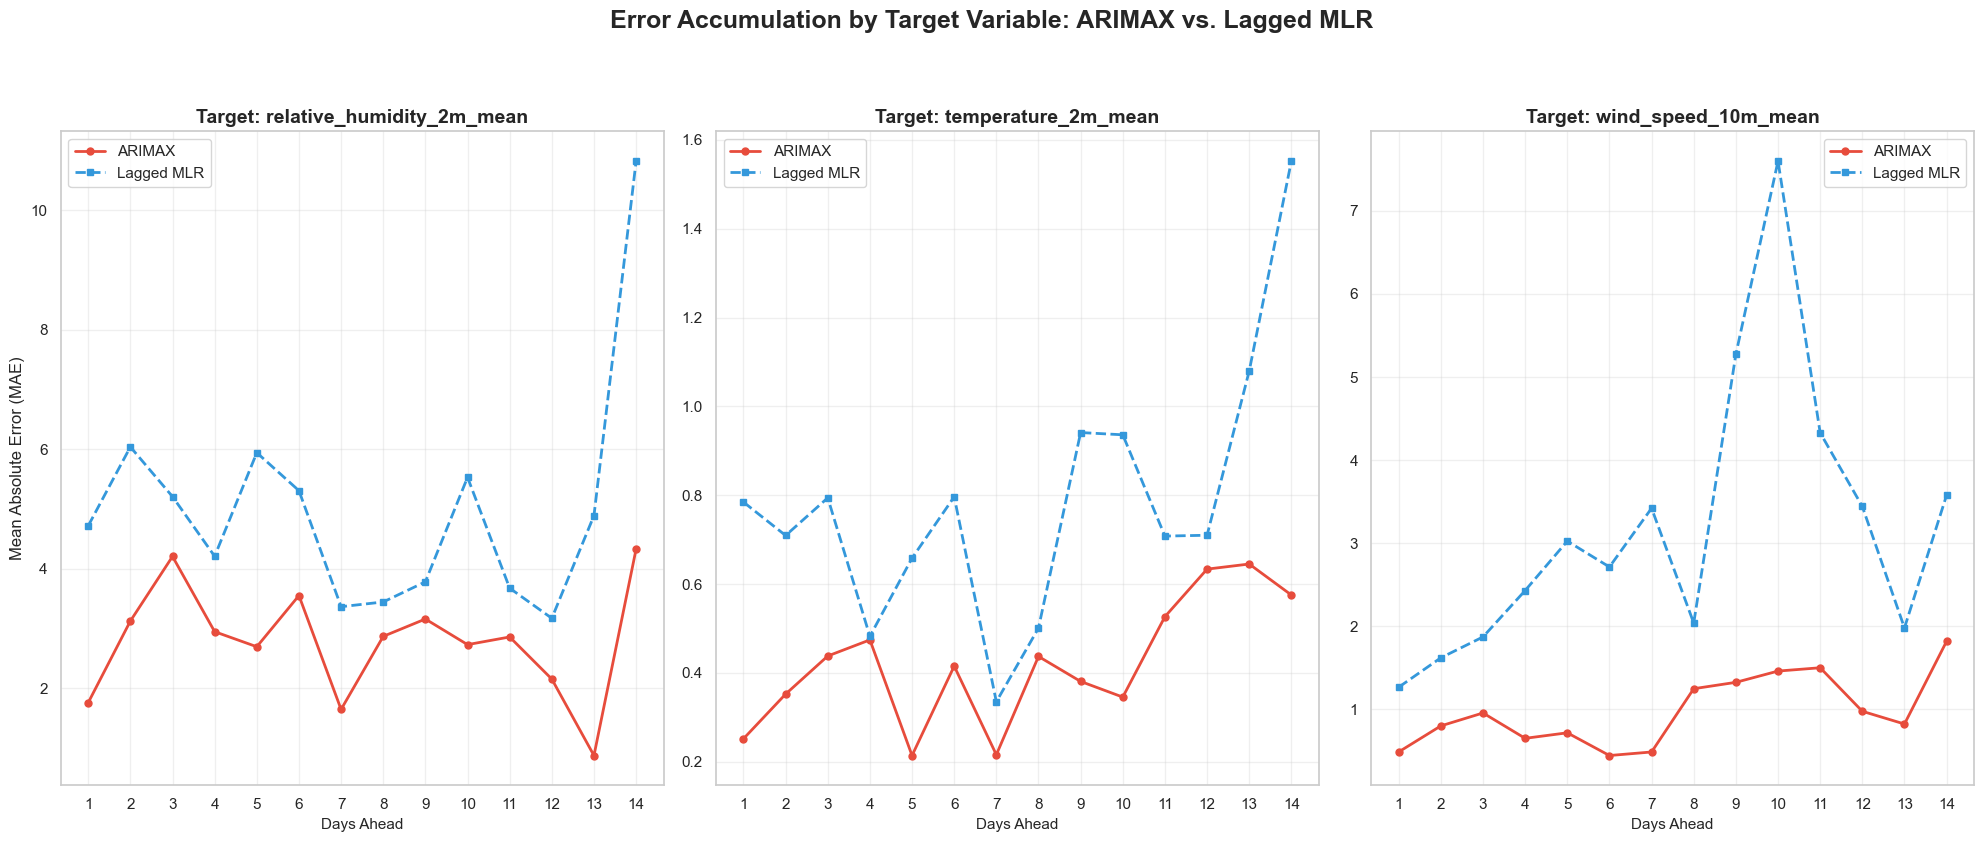

In [130]:
arimax_growth = results_master_df.groupby(['Target_Variable', 'Day_Ahead'])['Absolute_Error'].mean().reset_index()
mlr_growth = mlr_results_master_df.groupby(['Target_Variable', 'Day_Ahead'])['Absolute_Error'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True)
fig.suptitle('Error Accumulation by Target Variable: ARIMAX vs. Lagged MLR', fontsize=18, fontweight='bold', y=1.05)

targets = arimax_growth['Target_Variable'].unique()
colors = {'ARIMAX': '#e74c3c', 'MLR': '#3498db'}

for i, target in enumerate(targets):
    ax = axes[i]

    ari_sub = arimax_growth[arimax_growth['Target_Variable'] == target]
    mlr_sub = mlr_growth[mlr_growth['Target_Variable'] == target]
    
    # Plot ARIMAX
    ax.plot(ari_sub['Day_Ahead'], ari_sub['Absolute_Error'], 
            label='ARIMAX', color=colors['ARIMAX'], marker='o', linewidth=2, markersize=5)
    
    # Plot MLR
    ax.plot(mlr_sub['Day_Ahead'], mlr_sub['Absolute_Error'], 
            label='Lagged MLR', color=colors['MLR'], marker='s', linestyle='--', linewidth=2, markersize=5)
    
    # Formatting
    ax.set_title(f'Target: {target}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Days Ahead', fontsize=11)
    if i == 0:
        ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
    
    ax.set_xticks(range(1, 15))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

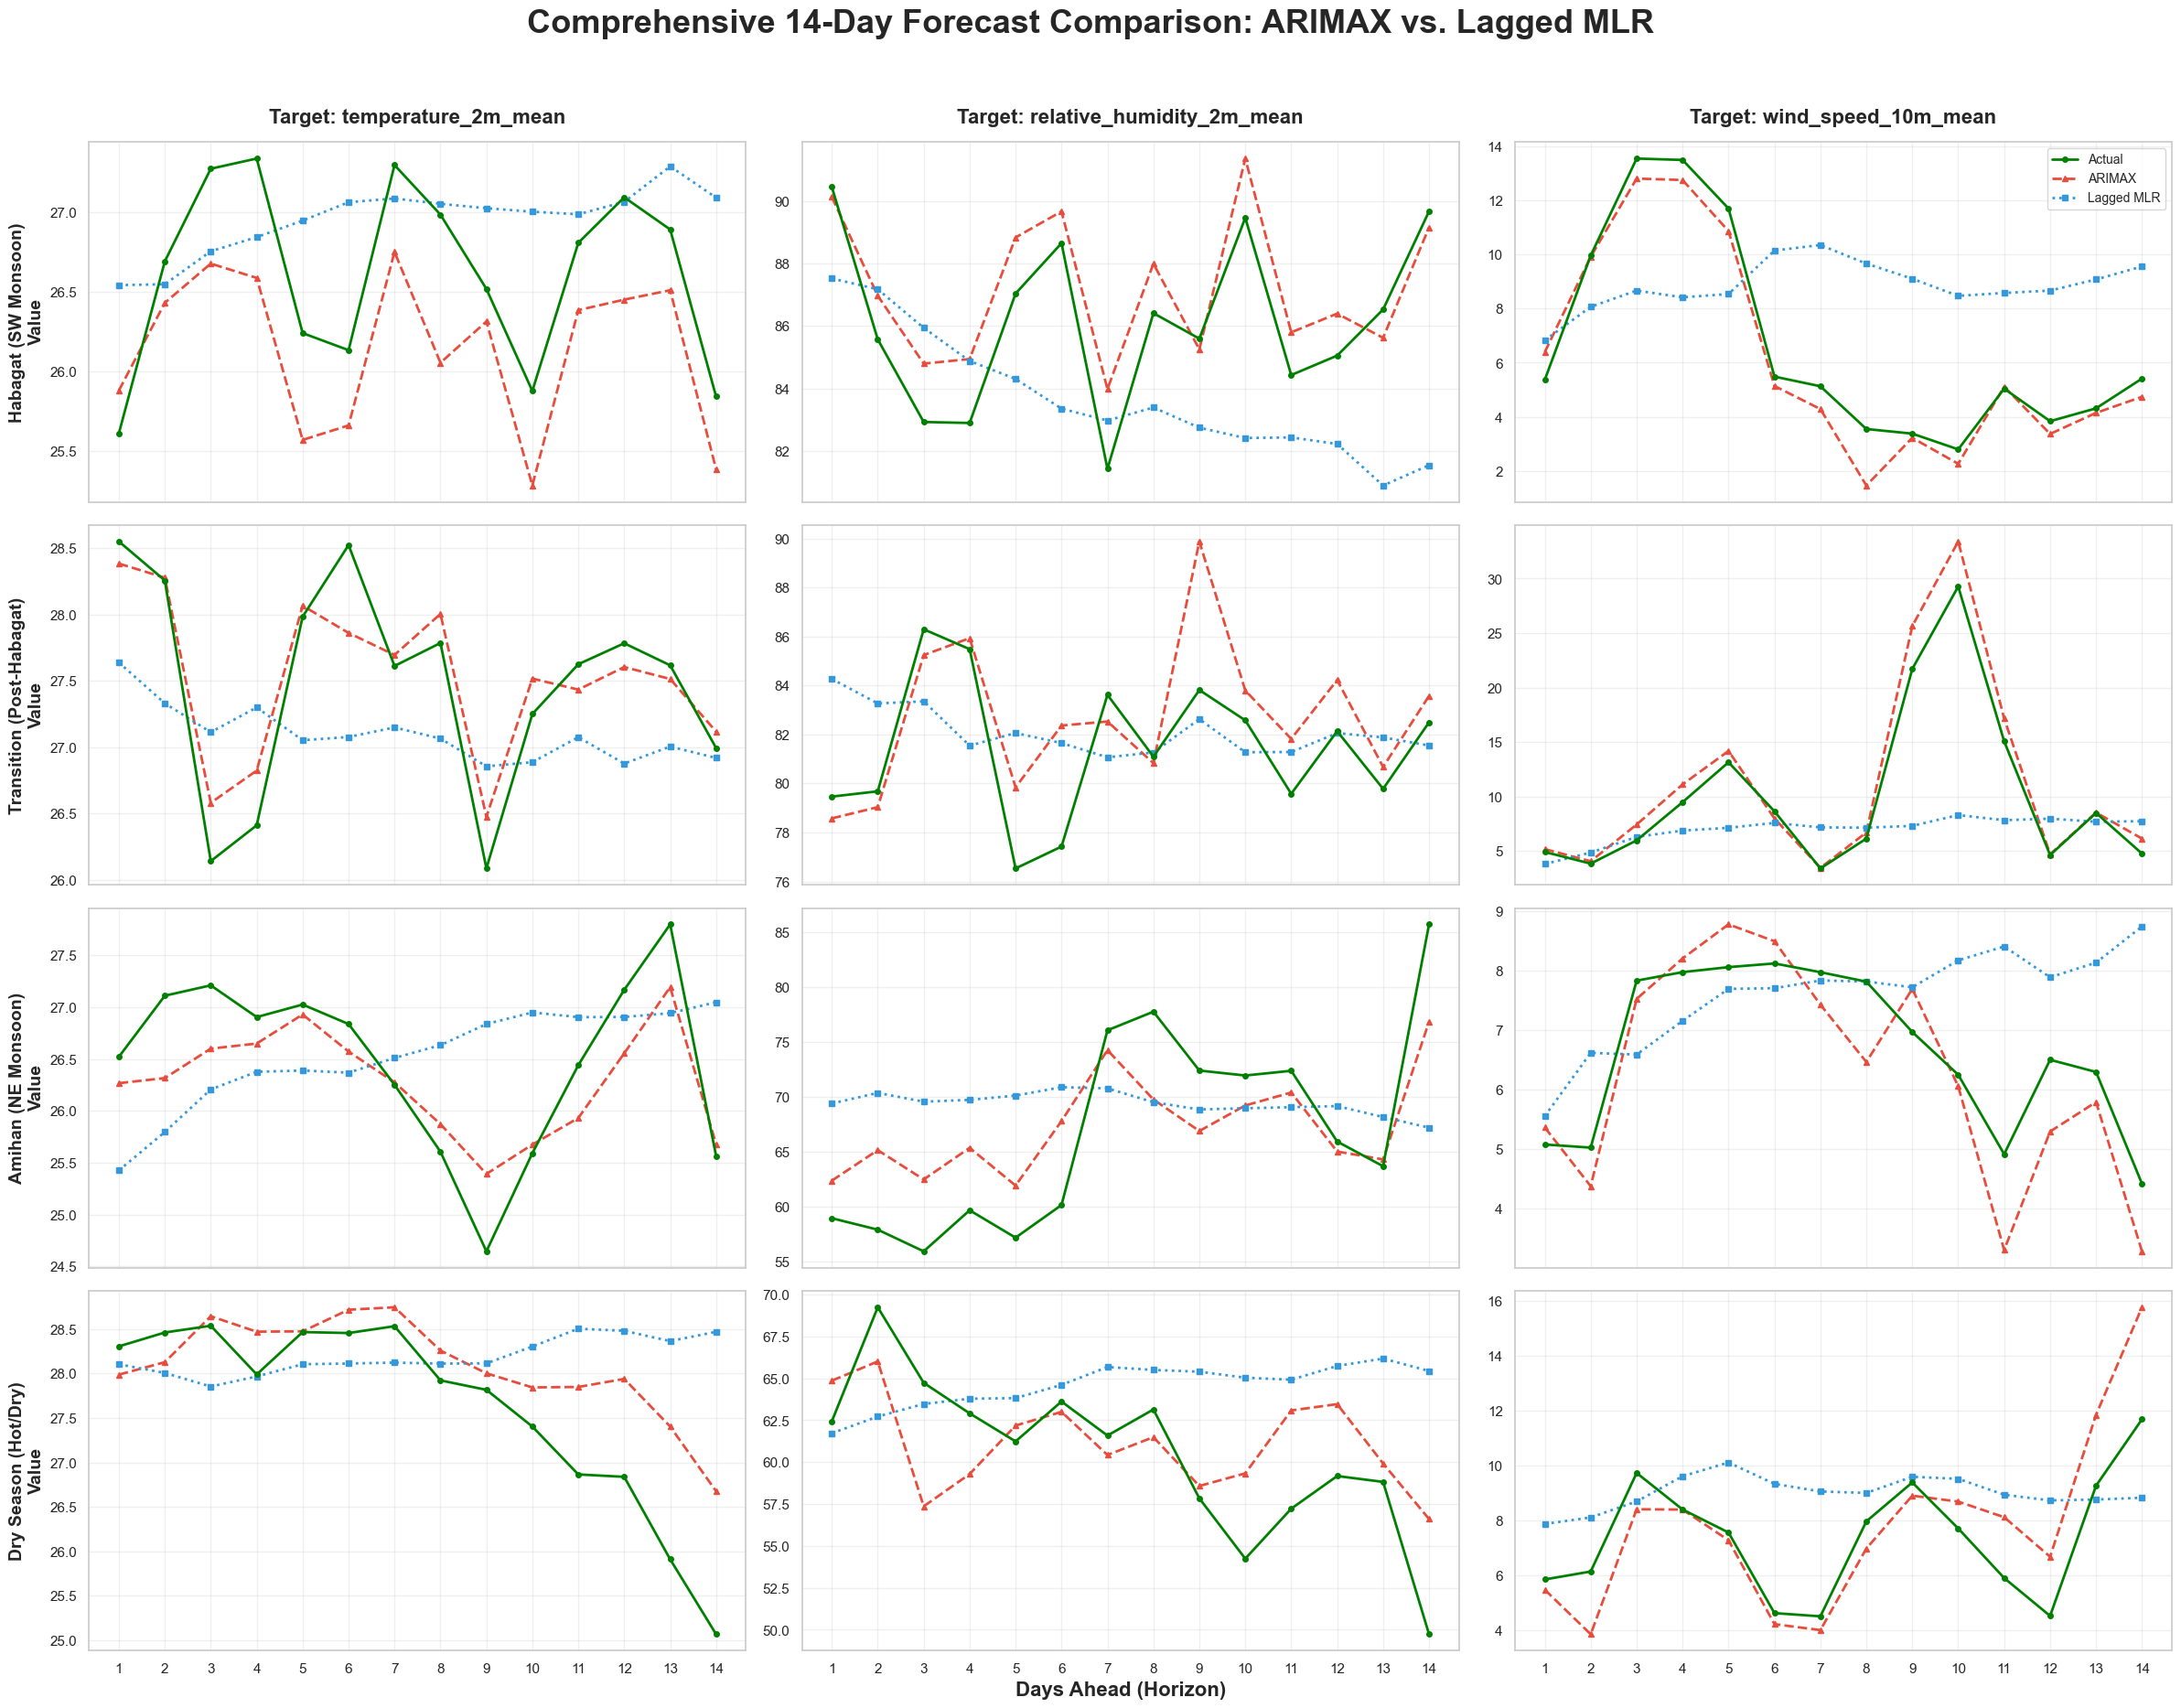

In [136]:
fig, axes = plt.subplots(4, 3, figsize=(24, 20), sharex=True)
fig.suptitle('Comprehensive 14-Day Forecast Comparison: ARIMAX vs. Lagged MLR', 
             fontsize=26, fontweight='bold', y=0.95)

seasons = results_master_df['Season'].unique()
targets = results_master_df['Target_Variable'].unique()

for i, season in enumerate(seasons):
    for j, target in enumerate(targets):
        ax = axes[i, j]
        
        ari_sub = results_master_df[(results_master_df['Season'] == season) & 
                                    (results_master_df['Target_Variable'] == target)]
        
        mlr_sub = mlr_results_master_df[(mlr_results_master_df['Season'] == season) & 
                                        (mlr_results_master_df['Target_Variable'] == target)]
        
        # actual
        ax.plot(ari_sub['Day_Ahead'], ari_sub['Actual_Value'], 
                label='Actual', color='green', linewidth=2, marker='o', markersize=4, zorder=3)
        
        # arimax
        ax.plot(ari_sub['Day_Ahead'], ari_sub['Predicted_Value'], 
                label='ARIMAX', color='#e74c3c', linestyle='--', linewidth=2, marker='^', markersize=4)
        
        # lagged mlr
        ax.plot(mlr_sub['Day_Ahead'], mlr_sub['Predicted_Value'], 
                label='Lagged MLR', color='#3498db', linestyle=':', linewidth=2, marker='s', markersize=4)

        if i == 0:
            ax.set_title(f'Target: {target}', fontsize=16, fontweight='bold', pad=15)
        if j == 0:
            ax.set_ylabel(f'{season}\nValue', fontsize=14, fontweight='bold')
        
        ax.set_xticks(range(1, 15))
        ax.grid(True, alpha=0.3)
        
        if i == 0 and j == 2:
            ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.xlabel('Days Ahead (Horizon)', fontsize=16, fontweight='bold', x=-0.6)
plt.show()